# 🛡️ IEEE-CIS Fraud Detection: Baseline Pipeline (v0.6.0)

## 📝 Introduction
This notebook documents the development of the preprocessing and feature selection pipeline for the **IEEE-CIS Fraud Detection** challenge. The primary goal of version **v0.6.0** is to establish a robust data engineering foundation, focusing on:
1. **Memory Efficiency:** Handling large-scale datasets with optimized footprints.
2. **Data Consolidation:** Strategic joining of Transaction and Identity tables.
3. **Dimensionality Reduction:** Statistical filters for feature selection and redundancy removal.

---

## 📍 Implementation Summary (v0.6.0 Roadmap)
* [**Data Description**](#data-description) 📖 *Reference*

* [**1. Memory Management**](#memory-management) 🟢 *Completed*
    * *Implementation of `DataOptimizer` for statistical downcasting.*
* [**2. Data Consolidation (Vesta Joiner)**](#data-joining) 🟡 *In Progress*
    * *Optimized merge between `train_transaction` and `train_identity`.*
* [**3. Feature Selection: Correlation Filter**](#correlation) ⚪ *Pending*
    * *Redundancy removal via Pearson/Spearman correlation matrices.*
* [**4. Feature Selection: Information Value (IV) & WoE**](#iv-woe) ⚪ *Pending*
    * *Statistical importance ranking relative to the `isFraud` target.*
* [**5. Baseline Export**](#export) ⚪ *Pending*
    * *Final generation of the cleaned dataset for initial modeling.*

---

In [12]:
import datetime
import gc
import os
import sys
import time

import lightgbm as lgb
import numpy as np
import pandas as pd
from bayes_opt import BayesianOptimization
from matplotlib import pyplot as plt
from scipy.stats import ks_2samp as ks_2sample
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Add the project root to the sys.path so we can import 'model_track'
# This assumes the notebook is in 'examples/' or 'notebooks/'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(os.path.join(project_root, "src"))

In [13]:
from model_track.binning.tree_binner import TreeBinner
from model_track.preprocessing.auditor import DataAuditor
from model_track.preprocessing.encoders import OrdinalEncoder
from model_track.preprocessing.memory import DataOptimizer
from model_track.preprocessing.types import TypeDetector
from model_track.stats.selection import StatisticalSelector
from model_track.woe.stability import CategoryMapper, WoeStability

# 1. Simulação de Dados de Treino (Referência)
df_a = pd.DataFrame(
    {
        "ID": [1, 2, 3, 4],
        "Score_Vesta": [0.85, 0.12, 0.33, 0.99],
        "Categoria": pd.Series(["A", "B", "A", "C"]).astype("category"),
        "Target": [0, 0, 1, 0],
        "Calculo_Interno": [10.0000001, 20.0, 30.0, 40.0],
    }
)

# 2. Simulação de Dados de Teste (Com 3 problemas propositais)
df_b = pd.DataFrame(
    {
        "ID": [5, 6],
        "Score_Vesta": [0.86, 0.13],
        # ERRO 1: 'Categoria' está como Object aqui, não Category
        "Categoria": ["A", "D"],
        # ERRO 2: 'Calculo_Interno' tem um erro de precisão maior que 1e-6
        "Calculo_Interno": [10.00002, 20.0],
        # ERRO 3: 'Nova_Feature' só existe no teste
        "Nova_Feature": [1, 0],
        # NOTA: 'Target' não existe no teste (comum em produção)
    }
)

# 3. Executando a Comparação
auditor = DataAuditor(target="Target")

print("🧪 Iniciando simulação de auditoria...")
res = auditor.compare_schemas(df_a, df_b, tolerance=1e-6)

print(f"\n✅ Schemas Idênticos? {res['is_equal']}")

print(f"\n📌 Colunas só no A: {res['only_in_a']}")
# Esperado: ['Target'] (o auditor ignora o target se configurado no init)

print(f"📌 Colunas só no B: {res['only_in_b']}")
# Esperado: ['Nova_Feature']

print(f"⚠️ Colunas com Divergência de Valor: {res['diff_value_cols']}")
# Esperado: ['Calculo_Interno'] porque a diferença 0.0000199 > 1e-6

# 4. Verificando o Sumário do Teste para ver se o tipo 'object' vs 'category' aparece
print("\n📊 Sumário do Dataset de B:")
summary_test = auditor.get_summary(df_b)
display(summary_test[["dtype", "unique_examples"]])

🧪 Iniciando simulação de auditoria...

✅ Schemas Idênticos? False

📌 Colunas só no A: []
📌 Colunas só no B: ['Nova_Feature']
⚠️ Colunas com Divergência de Valor: ['Categoria', 'Score_Vesta', 'Calculo_Interno', 'ID']

📊 Sumário do Dataset de B:


,dtype,unique_examples
column_name,,
ID,int64,"5, 6"
Score_Vesta,float64,"0.13, 0.86"
Categoria,object,"A, D"
Calculo_Interno,float64,"10.00002, 20.0"
Nova_Feature,int64,"0, 1"


<a id='data-description'></a>
## 📊 Data Description
The dataset consists of two main files linked by `TransactionID`. 

### 💳 Transaction Table (`train_transaction.csv`)
* **TransactionDT:** Timestep from a given reference datetime (not a real timestamp).
* **TransactionAmt:** Transaction payment amount in USD.
* **ProductCD:** Product code for each transaction.
* **card1 - card6:** Payment card information (card type, card bank, country, etc.).
* **addr1, addr2:** Address information.
* **dist:** Distance between address and billing information.
* **P_emaildomain / R_emaildomain:** Purchaser and recipient email domains.
* **C1 - C14:** Counting variables (e.g., how many addresses are found associated with the card).
* **D1 - D15:** Timedeltas, such as days between previous transactions.
* **M1 - M9:** Match indicators (names on card, address, etc.).
* **V1 - V339:** Vesta engineered features (ranking, counting, and other relations).

### 🆔 Identity Table (`train_identity.csv`)
Variables in this table are network connection information and digital signatures associated with transactions.
* **DeviceType:** Mobile or Desktop.
* **DeviceInfo:** Specific device models.
* **id_01 - id_38:** Behavioral and identity features.

---

<a id='memory-management'></a>
## 📦 1. Load dos dados e Memory Management (DataOptimizer)
The **IEEE-CIS** dataset contains over 400 columns and millions of rows. Loading this into standard 64-bit containers can easily exceed 2GB+ of RAM. Our `DataOptimizer` performs statistical downcasting to minimize the footprint without losing precision.

In [14]:
# 1. Configuração de caminhos (ajuste conforme sua estrutura local)
folder_path = "data/ieee-fraud-detection/"

# --- PROCESSAMENTO DO DATASET DE TREINO ---
print("📦 [STEP 1] PROCESSING TRAIN DATA")

print("\n🚀 Loading & Optimizing Identity (Train):")
# Lemos e já passamos pelo otimizador na mesma linha para economizar overhead
df_train_identity = pd.read_csv(f"{folder_path}train_identity.csv")
# Otimizamos e substituímos a variável antiga
df_train_identity = DataOptimizer.reduce_mem_usage(df_train_identity)
print(f"Memory Identity: {df_train_identity.memory_usage().sum() / 1024**2:.2f} MB")

print("\n🚀 Loading & Optimizing Transactions (Train):")
train_transaction = pd.read_csv(f"{folder_path}train_transaction.csv")
train_transaction = DataOptimizer.reduce_mem_usage(train_transaction)

print("\n🔗 Joining Train Datasets...")
df_train = pd.merge(train_transaction, df_train_identity, on="TransactionID", how="left")

# LIMPEZA CRÍTICA: Deletamos as tabelas originais que já foram mergeadas
del df_train_identity, train_transaction
gc.collect()
print("✅ Train fragments cleared from RAM.")

print("-" * 50)

# --- PROCESSAMENTO DO DATASET DE TESTE ---
print("📦 [STEP 2] PROCESSING TEST DATA")

print("\n🚀 Loading & Optimizing Identity (Test):")
df_test_identity = pd.read_csv(f"{folder_path}test_identity.csv")
df_test_identity = DataOptimizer.reduce_mem_usage(df_test_identity)

print("\n🚀 Loading & Optimizing Transactions (Test):")
test_transaction = pd.read_csv(f"{folder_path}test_transaction.csv")
test_transaction = DataOptimizer.reduce_mem_usage(test_transaction)

print("\n🔗 Joining Test Datasets...")
df_test = pd.merge(test_transaction, df_test_identity, on="TransactionID", how="left")

# LIMPEZA CRÍTICA: Deletamos as tabelas originais de teste
del df_test_identity, test_transaction
gc.collect()
print("✅ Test fragments cleared from RAM.")

# --- SUMÁRIO FINAL DE MEMÓRIA ---
print("\n" + "=" * 50)
print("🔥 FINAL PIPELINE STATUS:")
print(f"TRAIN: {df_train.shape[0]} rows | {df_train.shape[1]} columns")
print(f"TEST:  {df_test.shape[0]} rows | {df_test.shape[1]} columns")
print(f"Final TRAIN Memory: {df_train.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Final TEST Memory:  {df_test.memory_usage().sum() / 1024**2:.2f} MB")
print("=" * 50)

# Carregando o sample submission apenas para referência futura
sub = pd.read_csv(f"{folder_path}sample_submission.csv")

📦 [STEP 1] PROCESSING TRAIN DATA

🚀 Loading & Optimizing Identity (Train):
📉 Memória Inicial: 45.12 MB
✅ Memória Final:   16.05 MB
🚀 Redução de:      29.07 MB (64.4%)
Memory Identity: 16.05 MB

🚀 Loading & Optimizing Transactions (Train):
📉 Memória Inicial: 1775.15 MB
✅ Memória Final:   861.11 MB
🚀 Redução de:      914.04 MB (51.5%)

🔗 Joining Train Datasets...
✅ Train fragments cleared from RAM.
--------------------------------------------------
📦 [STEP 2] PROCESSING TEST DATA

🚀 Loading & Optimizing Identity (Test):
📉 Memória Inicial: 44.39 MB
✅ Memória Final:   15.80 MB
🚀 Redução de:      28.59 MB (64.4%)

🚀 Loading & Optimizing Transactions (Test):
📉 Memória Inicial: 1519.24 MB
✅ Memória Final:   738.36 MB
🚀 Redução de:      780.87 MB (51.4%)

🔗 Joining Test Datasets...
✅ Test fragments cleared from RAM.

🔥 FINAL PIPELINE STATUS:
TRAIN: 590540 rows | 434 columns
TEST:  506691 rows | 433 columns
Final TRAIN Memory: 924.29 MB
Final TEST Memory:  792.58 MB


<a id='data-diagnostics'></a>
## 🔍 2. Data Inventory & Missing Value Analysis
Using our `model_track` library to audit the merged datasets. We need to:
1. Identify the **Target** column and ensure it only exists in the Train set.
2. Analyze the **Missing Values** (NaNs) to prioritize future imputation or column removal.

In [15]:
# 1. Check for Target Column presence
target = "isFraud"
has_target_train = target in df_train.columns
has_target_test = target in df_test.columns

print(f"🛠️ Target Check ({target}):")
print(f"  - Present in Train: {'✅ Yes' if has_target_train else '❌ No'}")
print(f"  - Present in Test:  {'❌ Yes (Wait, what?)' if has_target_test else '✅ No'}")

column_time_dt = "TransactionDT"
# 2 Consistency Check: Identify columns in Train not in Test (excluding target)
cols_not_in_test = [
    c for c in df_train.columns if c not in df_test.columns and c not in [target, column_time_dt]
]
print(f"\n⚠️ Columns in Train but missing in Test (excluding target): {cols_not_in_test}")
feat_cols = [
    c for c in df_train.columns if c in df_test.columns and c not in [target, column_time_dt]
]

df_train = df_train[feat_cols + [target, column_time_dt]]
df_test = df_test[feat_cols + [column_time_dt]]
# 2. Get Summary using the library
print("\n📊 Generating Dataset Summary...")

auditor = DataAuditor(target="isFraud")
df_train_summary = auditor.get_summary(df_train[feat_cols]).reset_index()

# 3. Sorting by Missing Values (%)
# Geralmente o get_summary retorna um DataFrame com a coluna 'missing_pct' ou 'null_count'
df_train_summary_sorted = df_train_summary.sort_values(by="pct_na", ascending=False)

print("\n🔝 Top 15 Columns with most Missing Values (Train):")
display(df_train_summary_sorted.head(15))


print("\n🔝 Top 15 Columns with most top class pct(Train):")
display(df_train_summary.sort_values(by="top_class_pct", ascending=False).head(15))

🛠️ Target Check (isFraud):
  - Present in Train: ✅ Yes
  - Present in Test:  ✅ No

⚠️ Columns in Train but missing in Test (excluding target): ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

📊 Generating Dataset Summary...

🔝 Top 15 Columns with most Missing Values (Train):


,column_name,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
12,dist2,float32,552913,93.628374,1751,0.0,11623.000000,7.0,0.963017,Too many values...
35,D7,float32,551623,93.409930,597,0.0,843.000000,0.0,3.578928,Too many values...
41,D13,float32,528588,89.509263,577,0.0,847.000000,0.0,8.270397,Too many values...
42,D14,float32,528353,89.469469,802,-193.0,878.000000,0.0,7.665188,Too many values...
40,D12,float32,525823,89.041047,635,-83.0,648.000000,0.0,7.240153,Too many values...
34,D6,float32,517353,87.606767,829,-83.0,873.000000,0.0,7.752565,Too many values...
36,D8,float32,515614,87.312290,12353,0.0,1707.791626,0.791666,0.228774,Too many values...
37,D9,float32,515614,87.312290,24,0.0,0.958333,0.791666,0.912385,Too many values...
210,V158,float32,508595,86.123717,25,0.0,24.000000,1.0,9.270160,Too many values...
207,V155,float32,508595,86.123717,25,0.0,24.000000,1.0,9.920412,Too many values...



🔝 Top 15 Columns with most top class pct(Train):


,column_name,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
357,V305,float32,12,0.002032,2,1.0,2.0,1.0,99.997291,"1.0, 2.0"
159,V107,float32,314,0.053172,2,0.0,1.0,1.0,99.904833,"0.0, 1.0"
169,V117,float32,314,0.053172,4,0.0,3.0,1.0,99.823721,"0.0, 1.0, 2.0, 3.0"
171,V119,float32,314,0.053172,4,0.0,3.0,1.0,99.815423,"0.0, 1.0, 2.0, 3.0"
170,V118,float32,314,0.053172,4,0.0,3.0,1.0,99.779524,"0.0, 1.0, 2.0, 3.0"
172,V120,float32,314,0.053172,4,0.0,3.0,1.0,99.776137,"0.0, 1.0, 2.0, 3.0"
174,V122,float32,314,0.053172,4,0.0,3.0,1.0,99.713144,"0.0, 1.0, 2.0, 3.0"
163,V111,float32,314,0.053172,10,0.0,9.0,1.0,99.654384,"0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0"
165,V113,float32,314,0.053172,10,0.0,9.0,1.0,99.598334,"0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0"
17,C3,float32,0,0.000000,27,0.0,26.0,0.0,99.588682,Too many values...


In [16]:
# 1. Define thresholds
NULL_THRESHOLD = 98.0
CONST_THRESHOLD = 99.0

# 2. Identify columns - Ensuring we get the string names
# We access the 'column_name' column specifically
cols_to_drop_null = df_train_summary[df_train_summary["pct_na"] > NULL_THRESHOLD][
    "column_name"
].tolist()
cols_to_drop_const = df_train_summary[df_train_summary["top_class_pct"] > CONST_THRESHOLD][
    "column_name"
].tolist()

# Combine and remove duplicates
all_cols_to_drop = list(set(cols_to_drop_null + cols_to_drop_const))

# 🛑 Guardrail: Remove names only if they actually exist in the dataframe
all_cols_to_drop = [
    c for c in all_cols_to_drop if c in df_train.columns and c not in [target, "TransactionID"]
]

print(f"📉 Found {len(cols_to_drop_null)} columns with > {NULL_THRESHOLD}% NaNs.")
print(f"📉 Found {len(cols_to_drop_const)} columns with > {CONST_THRESHOLD}% top class.")
print(f"🗑️ Total unique columns to be removed: {len(all_cols_to_drop)}")

# 3. Perform the drop
df_train.drop(columns=all_cols_to_drop, inplace=True)
df_test.drop(columns=all_cols_to_drop, inplace=True)

print(f"\n✅ Cleanup complete. Dropped: {all_cols_to_drop[:5]}...")

📉 Found 0 columns with > 98.0% NaNs.
📉 Found 15 columns with > 99.0% top class.
🗑️ Total unique columns to be removed: 15

✅ Cleanup complete. Dropped: ['V119', 'V118', 'V120', 'C3', 'V107']...


In [17]:
# --- SUMÁRIO FINAL DE MEMÓRIA ---
print("\n" + "=" * 50)
print("🔥 FINAL PIPELINE STATUS:")
print(f"TRAIN: {df_train.shape[0]} rows | {df_train.shape[1]} columns")
print(f"TEST:  {df_test.shape[0]} rows | {df_test.shape[1]} columns")
print(f"Final TRAIN Memory: {df_train.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Final TEST Memory:  {df_test.memory_usage().sum() / 1024**2:.2f} MB")
print("=" * 50)


🔥 FINAL PIPELINE STATUS:
TRAIN: 590540 rows | 381 columns
TEST:  506691 rows | 380 columns
Final TRAIN Memory: 829.09 MB
Final TEST Memory:  710.90 MB


## 3. Detectando os tipos dos dados

In [18]:
def apply_month_year_engineering(df):
    # 1. Definir a data de referência (Anchor Date)
    start_date = datetime.datetime.strptime("2017-12-01", "%Y-%m-%d")

    # 2. Converter segundos em DateTime real
    # Usamos o timedelta para somar os segundos ao início
    df["dt_temp"] = df["TransactionDT"].apply(lambda x: start_date + datetime.timedelta(seconds=x))

    # 3. Criar a coluna Anomes (Formato numérico YYYYMM para fácil ordenação)
    df["tm_yymm"] = df["dt_temp"].dt.year * 100 + df["dt_temp"].dt.month

    # 4. Criar a coluna Ano-Mês (Formato string YYYY-MM para gráficos)
    df["tm_yymm_str"] = df["dt_temp"].dt.strftime("%Y-%m")

    # Remover a coluna temporária para economizar memória
    df.drop(columns=["dt_temp"], inplace=True)

    return df


# Aplicando nos dois datasets
df_train = apply_month_year_engineering(df_train)
df_test = apply_month_year_engineering(df_test)

print("✅ Colunas de período criadas: 'tm_yymm' (Int) e 'tm_yymm_str' (String)")
display(df_train[["TransactionDT", "tm_yymm", "tm_yymm_str"]].head())

✅ Colunas de período criadas: 'tm_yymm' (Int) e 'tm_yymm_str' (String)


,TransactionDT,tm_yymm,tm_yymm_str
0,86400,201712,2017-12
1,86401,201712,2017-12
2,86469,201712,2017-12
3,86499,201712,2017-12
4,86506,201712,2017-12


In [19]:
# %% etectando Tipos de Dados

print("🔍 Detectando perfis das variáveis...")
detector = TypeDetector(
    target="isFraud",
    id_cols=["TransactionID"],
    datetime_cols=["TransactionDT", "tm_yymm", "tm_yymm_str"],  # Informando explicitamente
)
feature_types = detector.detect(df_train)

for k, v in feature_types.items():
    print(f"{k.upper():<20} | {len(v):<5}")

🔍 Detectando perfis das variáveis...
DATETIME             | 3    
CATEGORICAL_LOW      | 109  
CATEGORICAL_HIGH     | 3    
NUMERICAL            | 266  
ID_LIKE              | 0    


In [20]:
feature_types.get("categorical_high")

['P_emaildomain', 'R_emaildomain', 'DeviceInfo']

## Dividir os dados de treino em dois períodos, treino e validacao 

Iremos dividir os dados de treino segundo as datas, usaremos os primeiros meses como dev e os dois últimos como oot.

In [21]:
# Iremos dividir os dados de treino segundo as datas, usaremos os primeiros meses como dev e os dois últimos como oot.
df_train["Amostra"] = df_train["tm_yymm"].apply(lambda x: "dev" if x <= 201804 else "oot")
print("✅ Coluna 'Amostra' criada com base em 'tm_yymm'.")
display(df_train[["tm_yymm", "Amostra"]].drop_duplicates().sort_values(by="tm_yymm").head(10))

✅ Coluna 'Amostra' criada com base em 'tm_yymm'.


,tm_yymm,Amostra
0,201712,dev
134339,201801,dev
226849,201802,dev
312574,201803,dev
414542,201804,dev
498113,201805,oot
587786,201806,oot


<a id='tree-binning'></a>
## 🌳 4. Supervised Binning (TreeBinner)
We will now use a Decision Tree-based approach to discretize continuous features. 
* **Mechanism:** The `TreeBinner` finds optimal split points by maximizing the information gain relative to the `isFraud` target.
* **Benefit:** This automatically handles outliers and non-linear relationships by grouping values with similar fraud probabilities.
* **Post-Processing:** All resulting bins will be treated as categorical strings, with `NaN` values mapped to a dedicated `"N/A"` category.

In [22]:
# 1. Identify potential continuous features
numerical_features = feature_types.get("numerical")
# [c+'_freq' for c in feature_types.get('categorical_high')] + feature_types.get('numerical')
categorical_features = feature_types.get("categorical_low")

bins_dict = {}
train_bins = {}
test_bins = {}
cols_to_drop = []

start_total = time.time()


binners_map = {}  # Guardamos os binners para usar no Teste/Produção depois

for col in numerical_features:
    binner = TreeBinner(max_depth=3, min_samples_leaf=100)

    # Fit apenas no DEV
    binner.fit(df_train.query("Amostra == 'dev'"), column=col, target="isFraud")

    # Transform no Treino e Teste
    df_train[f"{col}_bin"] = binner.transform(df_train, column=col)
    df_test[f"{col}_bin"] = binner.transform(df_test, column=col)

    binners_map[col] = binner  # Salvando o estado

print(f"✅ Binarização concluída para {len(numerical_features)} colunas.")
print(f"\n✅ TreeBinner finished in {time.time() - start_total:.2f} seconds.")

gc.collect()

# 4. Final Verification
numerical_features_bin = [c for c in df_train.columns if c.endswith("_bin")]
print(f"Final Binned Columns Created: {len(numerical_features_bin)}")

display(df_train[numerical_features_bin].head())

/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_11837/2749909088.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f"{col}_bin"] = binner.transform(df_train, column=col)
/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_11837/2749909088.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[f"{col}_bin"] = binner.transform(df_train, column=col)
/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_11837/2749909088.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usua

✅ Binarização concluída para 266 colunas.

✅ TreeBinner finished in 197.67 seconds.
Final Binned Columns Created: 266


,TransactionAmt_bin,card1_bin,card2_bin,card3_bin,card5_bin,addr1_bin,addr2_bin,dist1_bin,dist2_bin,C1_bin,...,V330_bin,V331_bin,V332_bin,V333_bin,V334_bin,V335_bin,V336_bin,V337_bin,V338_bin,V339_bin
0,"(24.893, 135.238]","(13334.5, 15066.5]",N/A,"(149.5, 174.5]","(137.5, 162.5]","(198.5, 535.5]","(68.5, 90.5]","(3.5, 78.5]",N/A,"(0.5, 1.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,"(24.893, 135.238]","(-inf, 8754.0]","(201.5, 499.5]","(149.5, 174.5]","(-inf, 108.0]","(198.5, 535.5]","(68.5, 90.5]",N/A,N/A,"(0.5, 1.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,"(24.893, 135.238]","(-inf, 8754.0]","(201.5, 499.5]","(149.5, 174.5]","(162.5, 168.0]","(198.5, 535.5]","(68.5, 90.5]","(78.5, 958.5]",N/A,"(0.5, 1.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,"(24.893, 135.238]","(15066.5, inf]","(553.5, inf]","(149.5, 174.5]","(108.0, 136.5]","(198.5, 535.5]","(68.5, 90.5]",N/A,N/A,"(1.5, 4.5]",...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
4,"(24.893, 135.238]","(-inf, 8754.0]","(500.5, 553.5]","(149.5, 174.5]","(-inf, 108.0]","(198.5, 535.5]","(68.5, 90.5]",N/A,N/A,"(0.5, 1.5]",...,"(-inf, 0.5]","(-inf, 2.5]","(-inf, 3.24]","(-inf, 2.5]","(-inf, 15.5]","(-inf, 59.0]","(-inf, 5.5]","(-inf, 2.5]","(-inf, 2.5]","(-inf, 2.5]"


<a id='iv-cramers'></a>
## 📊 5. Statistical Selection: IV & Cramer's V
To finalize our feature set, we apply a dual-stage filter:
1. **Information Value (IV):** Drop features with $IV < 0.10$ (Weak predictive power).
2. **Cramer's V:** Identify redundant categorical pairs. If $V > 0.80$, we keep the feature with the **highest IV**.

In [23]:
# %% [NB Step 5] Statistical Selection: IV & Cramer's V
features_to_evaluate = (
    numerical_features_bin + categorical_features + feature_types.get("categorical_high")
)

selector = StatisticalSelector(iv_threshold=0.10, cramers_threshold=0.70, sample_size=50000)

print(f"📉 Avaliando {len(features_to_evaluate)} features...")
# O Fit toma as decisões com base no Treino
selector.fit(df_train, target="isFraud", features=features_to_evaluate)

# O Transform executa a remoção no Treino e no Teste
df_train = selector.transform(df_train)
df_test = selector.transform(df_test)

print(f"\n❌ Features descartadas: {len(selector.dropped_features_)}")
print(f"✅ Features finais mantidas: {len(selector.selected_features_)}")
features_finais = selector.selected_features_
# Exibindo o Top 10 IVs para auditoria visual
iv_df = pd.DataFrame(list(selector.iv_results_.items()), columns=["feature", "iv"])
display(iv_df.sort_values(by="iv", ascending=False).head(10))

# Atualizando as listas de variáveis finais
numerical_features_bin_selecionadas = [
    f for f in numerical_features_bin if f in selector.selected_features_
]
categorical_features_selecionadas = [
    f for f in categorical_features if f in selector.selected_features_
]
gc.collect()

📉 Avaliando 378 features...


/Users/cristianooliveira/Documents/model-track-cr/src/model_track/stats/selection.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby(target, group_keys=False, observed=True).apply(



❌ Features descartadas: 240
✅ Features finais mantidas: 138


,feature,iv
377,DeviceInfo,1.967828
194,V258_bin,0.988569
193,V257_bin,0.927573
139,V201_bin,0.924113
138,V200_bin,0.886558
318,V52,0.879626
179,V243_bin,0.859018
182,V246_bin,0.857816
126,V187_bin,0.852337
128,V189_bin,0.841501


0

In [24]:
auditor = DataAuditor(target="isFraud")
auditor.get_summary(df_train[feature_types.get("datetime")]).sort_values(
    by="n_distinct", ascending=False
)

,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
column_name,,,,,,,,,
TransactionDT,int32,0,0.0,573349,86400.0,15811131.0,9474817,0.001355,Too many values...
tm_yymm,int32,0,0.0,7,201712.0,201806.0,201712,22.748501,"201712, 201801, 201802, 201803, 201804, 201805..."
tm_yymm_str,object,0,0.0,7,NaN,NaN,2017-12,22.748501,"2017-12, 2018-01, 2018-02, 2018-03, 2018-04, 2..."


In [25]:
auditor.get_summary(df_train).sort_values(by="n_distinct", ascending=False)

,dtype,null_count,pct_na,n_distinct,min,max,top_class,top_class_pct,unique_examples
column_name,,,,,,,,,
TransactionID,int32,0,0.000000,590540,2987000.0,3577539.0,2987000,0.000169,Too many values...
TransactionDT,int32,0,0.000000,573349,86400.0,15811131.0,9474817,0.001355,Too many values...
V307,float32,12,0.002032,37367,0.0,145765.0,0.0,53.620415,Too many values...
V127,float32,314,0.053172,24414,0.0,160000.0,0.0,62.075050,Too many values...
V308,float32,12,0.002032,23064,0.0,108800.0,0.0,71.538592,Too many values...
...,...,...,...,...,...,...,...,...,...
card6,category,1571,0.266028,4,NaN,NaN,debit,74.497578,"charge card, credit, debit, debit or credit"
C5_bin,object,0,0.000000,4,NaN,NaN,"(-inf, 0.5]",63.066854,"(-inf, 0.5], (0.5, 1.5], (1.5, 107.5], (107.5,..."
V35,float32,168969,28.612626,4,0.0,3.0,1.0,37.488908,"0.0, 1.0, 2.0, 3.0"


## Otimização Bayesiana para LightGBM

In [26]:
# %% [NB Step 6] Pre-LGBM: Ordinal Encoding
# Inicializa o nosso Encoder (unseen_value=-1 é o padrão seguro para árvores)
encoder = OrdinalEncoder(unseen_value=-1)

print(f"⚙️ Codificando {len(features_finais)} features para o LightGBM...")

# FIT: Aprende o mapeamento APENAS na base 'dev' (Evita vazamento de dados do futuro/OOT)
encoder.fit(df_train.query("Amostra == 'dev'"), columns=features_finais)

# TRANSFORM: Aplica no Treino (Dev + OOT) e no Teste
df_train_lgbm = encoder.transform(df_train, columns=features_finais)
df_test_lgbm = encoder.transform(df_test, columns=features_finais)

print("✅ Encoding concluído com sucesso!")
display(df_train_lgbm[features_finais].head())

⚙️ Codificando 138 features para o LightGBM...
✅ Encoding concluído com sucesso!


,DeviceInfo,V258_bin,V201_bin,V52,V246_bin,V187_bin,C12_bin,V199_bin,C8_bin,V245_bin,...,V5,V143_bin,V82,V66,V140_bin,V61,V147_bin,V292_bin,TransactionAmt_bin,V307_bin
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,0,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,2
4,1,1,1,0,1,1,0,1,1,1,...,1,1,2,1,1,1,1,0,0,1


In [27]:
# %% [NB Step 7] Preparação para LightGBM e Otimização Bayesiana

# Criamos apenas as máscaras (gasta bytes de memória)
dev_mask = df_train_lgbm["Amostra"] == "dev"
oot_mask = df_train_lgbm["Amostra"] == "oot"


def lgbm_cl_bo(
    max_depth, num_leaves, learning_rate, feature_fraction, bagging_fraction, lambda_l1, lambda_l2
):
    params = {
        "objective": "binary",
        "metric": "auc",
        "is_unbalance": True,
        "boosting_type": "gbdt",
        "n_jobs": -1,
        "verbose": -1,
        "max_depth": int(max_depth),
        "num_leaves": int(num_leaves),
        "learning_rate": learning_rate,
        "feature_fraction": feature_fraction,
        "bagging_fraction": bagging_fraction,
        "lambda_l1": lambda_l1,
        "lambda_l2": lambda_l2,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Passamos os dados DIRETAMENTE usando a máscara
    score = cross_val_score(
        lgb.LGBMClassifier(**params),
        df_train_lgbm.loc[dev_mask, features_finais],
        df_train_lgbm.loc[dev_mask, "isFraud"],
        cv=cv,
        scoring="roc_auc",
    ).mean()
    return score


# Limites para a busca
params_bounds = {
    "max_depth": (3, 20),
    "num_leaves": (20, 300),
    "learning_rate": (0.01, 0.3),
    "feature_fraction": (0.3, 0.9),
    "bagging_fraction": (0.3, 0.9),
    "lambda_l1": (0, 5),
    "lambda_l2": (0, 5),
}

optimizer = BayesianOptimization(f=lgbm_cl_bo, pbounds=params_bounds, random_state=42)
print("🚀 Iniciando Otimização Bayesiana (LGBM)...")
optimizer.maximize(init_points=5, n_iter=15)

best_params = optimizer.max["params"]
for int_param in ["max_depth", "num_leaves"]:
    best_params[int_param] = int(best_params[int_param])

# Treinamento Final passando diretamente
final_model = lgb.LGBMClassifier(**best_params, objective="binary", metric="auc", is_unbalance=True)
final_model.fit(
    df_train_lgbm.loc[dev_mask, features_finais], df_train_lgbm.loc[dev_mask, "isFraud"]
)

print("✅ Modelo treinado com sucesso!")

🚀 Iniciando Otimização Bayesiana (LGBM)...
|   iter    |  target   | baggin... | featur... | lambda_l1 | lambda_l2 | learni... | max_depth | num_le... |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.8876    | 0.5247    | 0.8704    | 3.66      | 2.993     | 0.05525   | 5.652     | 36.26     |
| 2         | 0.9175    | 0.8197    | 0.6607    | 3.54      | 0.1029    | 0.2913    | 17.15     | 79.45     |
| 3         | 0.9097    | 0.4091    | 0.41      | 1.521     | 2.624     | 0.1353    | 7.951     | 191.3     |
| 4         | 0.9113    | 0.3837    | 0.4753    | 1.832     | 2.28      | 0.2377    | 6.394     | 164.0     |
| 5         | 0.9232    | 0.6554    | 0.3279    | 3.038     | 0.8526    | 0.02886   | 19.13     | 290.4     |
| 6         | 0.9322    | 0.8603    | 0.4897    | 2.536     | 0.2079    | 0.05302   | 19.77     | 290.2     |
| 7         | 0.9336    | 0.6434    | 0.54      | 1.063     | 0.9474    | 0.0

In [28]:
# Treinando o modelo final com os melhores parâmetros

final_model = lgb.LGBMClassifier(**best_params, objective="binary", metric="auc", is_unbalance=True)
final_model.fit(
    df_train_lgbm.loc[dev_mask, features_finais], df_train_lgbm.loc[dev_mask, "isFraud"]
)

# Criando o DataFrame de Importância
fi_df = pd.DataFrame(
    {
        "feature": df_train_lgbm.loc[dev_mask, features_finais].columns,
        "importance": final_model.feature_importances_,
    }
).sort_values(by="importance", ascending=False)

# Avaliando o desempenho no conjunto em dev com ks_2sample e auc
df_train_lgbm["pred_proba"] = final_model.predict_proba(df_train_lgbm[features_finais])[:, 1]
# aplicar groupby por tm_yymm_str e calcular ks_2sample e auc para cada grupo
performance_by_month = (
    df_train_lgbm.groupby("tm_yymm_str")
    .apply(
        lambda x: pd.Series(
            {
                "ks_2sample": ks_2sample(
                    x.loc[x["isFraud"] == 0, "pred_proba"], x.loc[x["isFraud"] == 1, "pred_proba"]
                ).statistic,
                "auc": roc_auc_score(x["isFraud"], x["pred_proba"]),
            }
        )
    )
    .reset_index()
)
print("\n📈 Performance by Month (KS 2-sample & AUC):")
print(performance_by_month)

print("\n🏆 Top 30 Features Selecionadas pelo LGBM:")
display(fi_df.head(30))

# Selecionando as Top X (Exemplo: Top 30) para a Regressão Logística posterior
top_features = fi_df.head(30)["feature"].tolist()

/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_11837/2500794356.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_lgbm['pred_proba'] = final_model.predict_proba(df_train_lgbm[features_finais])[:, 1]



📈 Performance by Month (KS 2-sample & AUC):
  tm_yymm_str  ks_2sample       auc
0     2017-12    0.826472  0.973800
1     2018-01    0.827272  0.973505
2     2018-02    0.850854  0.980140
3     2018-03    0.824542  0.973182
4     2018-04    0.843708  0.978888
5     2018-05    0.618536  0.882600
6     2018-06    0.637517  0.887562

🏆 Top 30 Features Selecionadas pelo LGBM:


/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_11837/2500794356.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  performance_by_month = df_train_lgbm.groupby('tm_yymm_str').apply(


,feature,importance
117,card2_bin,1236
95,card5_bin,1136
0,DeviceInfo,1096
75,R_emaildomain,860
89,D15_bin,856
92,C11_bin,823
113,C6_bin,772
77,C2_bin,665
86,D2_bin,664
136,TransactionAmt_bin,654


## Feature engineering nas top features

- Análise de woe e iv
- Junção de categorias
- Descarte de features não estáveis

In [29]:
# converter as features seleciondas para str, nan deve ser convertido para 'N/A' para evitar problemas de mapeamento
for f in top_features:
    df_train[f] = df_train[f].astype(str).fillna("N/A")
print(f"✅ Top {len(top_features)} features convertidas para string para a Regressão Logística.")
top_categorical_features = [f for f in categorical_features_selecionadas if f in top_features]
top_numerical_features = [f for f in numerical_features_bin_selecionadas if f in top_features]
print(f"📊 Top Categorical Features: {len(top_categorical_features)}")
print(f"📊 Top Numerical Features: {len(top_numerical_features)}")

✅ Top 30 features convertidas para string para a Regressão Logística.
📊 Top Categorical Features: 3
📊 Top Numerical Features: 25


In [ ]:
# %% [NB Step 8] Automação de Agrupamento de Categorias (Auto-Mapper Otimizado)

dict_joined_categories = {}

# Inicializa as classes
ws = WoeStability(date_col="tm_yymm_str")
mapper = CategoryMapper()

print("🤖 Iniciando Auto-Agrupamento de Categorias (Força Bruta Combinatória)...")

# Iteramos sobre todas as features que foram pro LightGBM
features_para_agrupar = top_categorical_features + top_numerical_features

# Iteramos sobre todas as features
for col_var in features_para_agrupar:
    df_train[col_var] = df_train[col_var].astype(str).fillna("N/A")
    df_test[col_var] = df_test[col_var].astype(str).fillna("N/A")

    matrix = ws.calculate_stability_matrix(df_train, feature_col=col_var, target_col="isFraud")

    # MÁGICA AQUI: Se a variável for numérica (veio do TreeBinner), ela é ordenada!
    eh_ordenada = col_var in top_numerical_features

    suggested_map = mapper.auto_group(matrix, min_groups=2, is_ordered=eh_ordenada)

    dict_joined_categories[col_var] = suggested_map

    # Visualização de Exemplo (Apenas para a primeira feature categórica para auditoria rápida)
    if len(top_categorical_features) > 0 and col_var == top_categorical_features[0]:
        print(f"\n📊 Exemplo de agrupamento sugerido para {col_var}:")
        display(pd.Series(suggested_map).to_frame(name="Novo_Grupo"))

print(f"✅ Auto-Mapeamento concluído para {len(dict_joined_categories)} colunas.")

# %% [NB Step 9] Aplicação Segura do Mapeamento
print("\n🔄 Aplicando mapeamentos nas bases...")

# Aplicamos coluna a coluna usando map(). Muito mais rápido e seguro que replace() global.
for col, col_map in dict_joined_categories.items():
    df_train[col] = df_train[col].map(col_map).fillna(df_train[col])
    df_test[col] = df_test[col].map(col_map).fillna(df_test[col])

print("✅ Todos os agrupamentos foram aplicados nos DataFrames!")

🤖 Iniciando Auto-Agrupamento de Categorias (Força Bruta Combinatória)...

📊 Exemplo de agrupamento sugerido para V61:


,Novo_Grupo
3.0,3.0 ou 6.0 ou 4.0
6.0,3.0 ou 6.0 ou 4.0
4.0,3.0 ou 6.0 ou 4.0
5.0,5.0 ou 2.0 ou nan ou 1.0
2.0,5.0 ou 2.0 ou nan ou 1.0
nan,5.0 ou 2.0 ou nan ou 1.0
1.0,5.0 ou 2.0 ou nan ou 1.0
0.0,<=0


✅ Auto-Mapeamento concluído para 28 colunas.

🔄 Aplicando mapeamentos nas bases...
✅ Todos os agrupamentos foram aplicados nos DataFrames!


🔍 Iniciando auditoria para 28 variáveis...



📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V61,,,,,,,,
3.0 ou 6.0 ou 4.0,155,600,0.0075,0.0011,0.0013,-1.9659,0.0127,0.0427
5.0 ou 2.0 ou nan ou 1.0,"18,254","472,704",0.8834,0.8295,0.8314,-0.0630,0.0034,0.0427
<=0,"2,254","96,573",0.1091,0.1695,0.1674,0.4403,0.0266,0.0427
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0427,0.0427


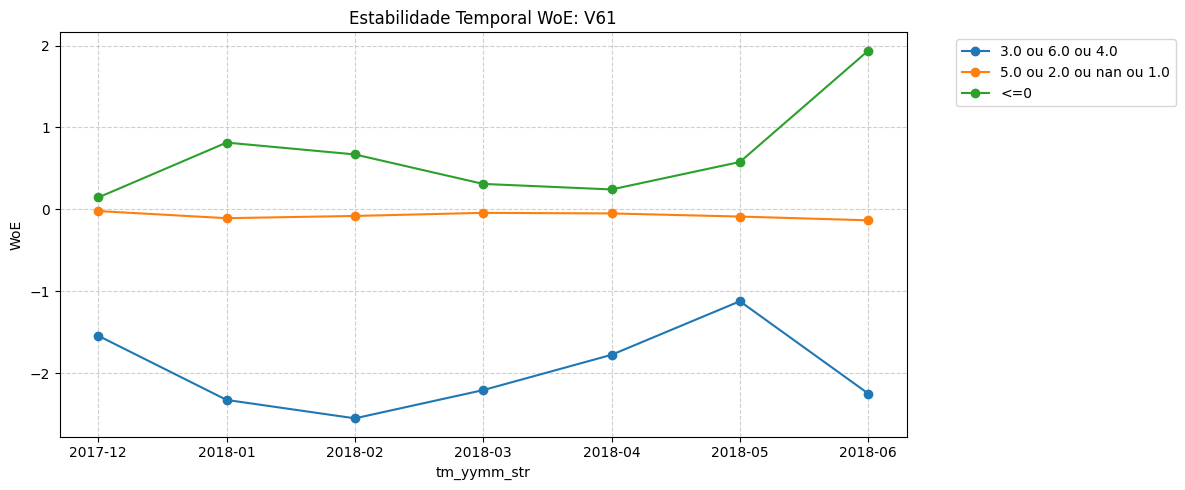

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V75,,,,,,,,
2 a 3 ou N/A,"4,715","88,275",0.2282,0.1549,0.1575,-0.3874,0.0284,0.0350
4.0 ou 0.0 ou 1.0,"15,948","481,602",0.7718,0.8451,0.8425,0.0907,0.0066,0.0350
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0350,0.0350


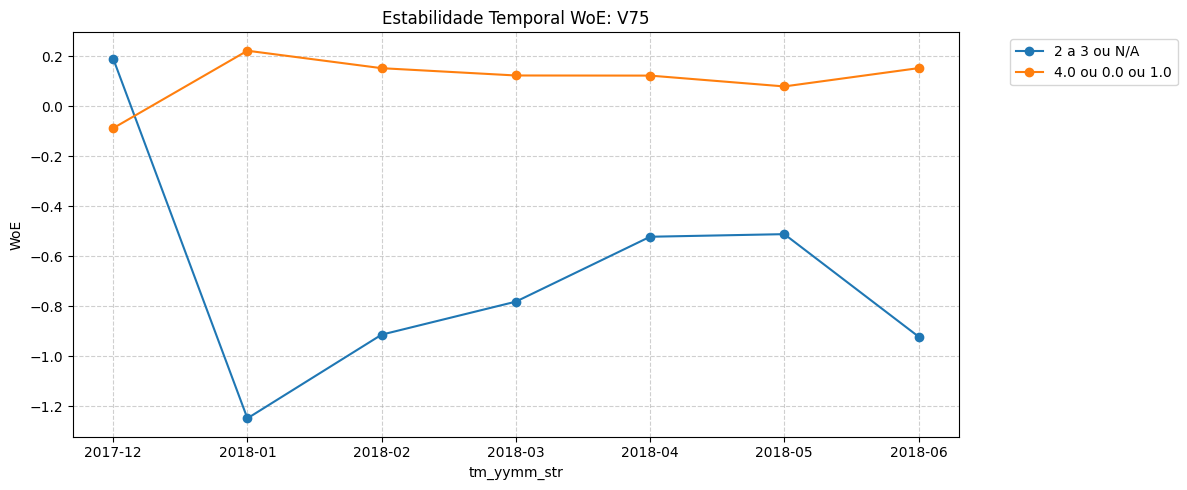

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V83,,,,,,,,
1,"12,635","383,984",0.6115,0.6738,0.6716,0.0970,0.0060,0.0990
<=0,"1,749","81,856",0.0846,0.1436,0.1416,0.5286,0.0312,0.0990
>=2 ou N/A,"6,279","104,037",0.3039,0.1826,0.1868,-0.5096,0.0618,0.0990
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0990,0.0990


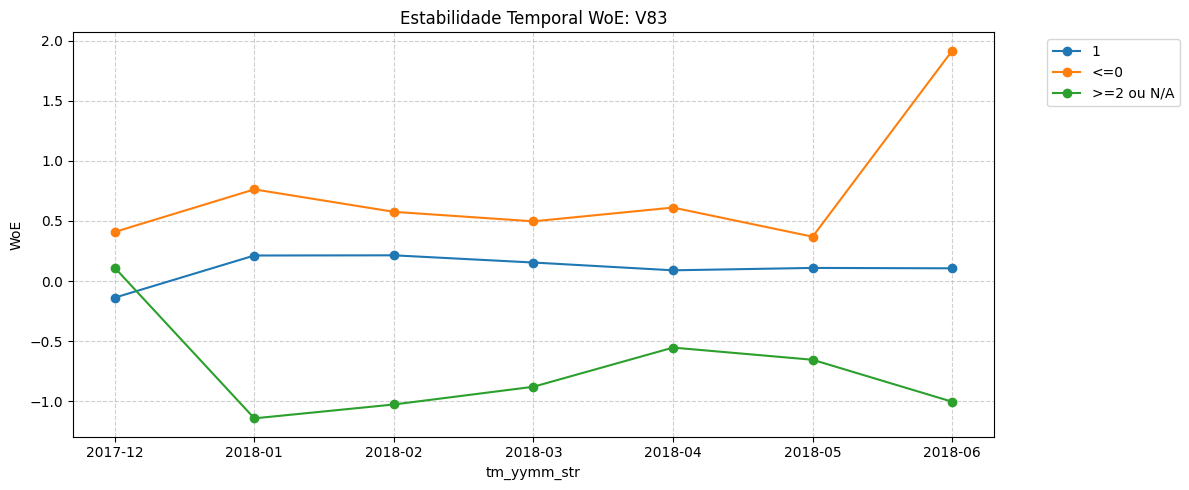

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
TransactionAmt_bin,,,,,,,,
"(-inf, 2.112] ou (18.418, 18.663] ou (18.663, 19.464] ou (2.112, 18.418]","2,159","23,788",0.1045,0.0417,0.0439,-0.9177,0.0576,0.1172
"(135.238, 150.442] ou (19.464, 24.893]","1,775","30,864",0.0859,0.0542,0.0553,-0.4615,0.0147,0.1172
"(150.442, inf]","5,391","119,843",0.2609,0.2103,0.2121,-0.2157,0.0109,0.1172
"(24.893, 135.238]","11,338","395,382",0.5487,0.6938,0.6887,0.2346,0.0340,0.1172
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1172,0.1172


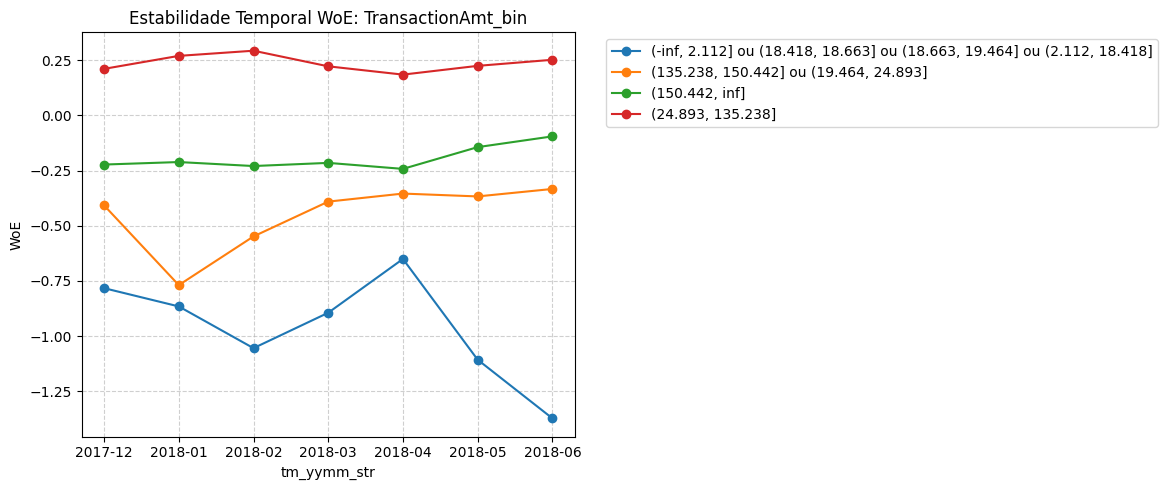

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
card2_bin,,,,,,,,
"(-inf, 175.5] ou N/A","4,389","114,935",0.2124,0.2017,0.2021,-0.0519,0.0006,0.1061
"(175.5, 181.5]",678,"3,581",0.0328,0.0063,0.0072,-1.6534,0.0439,0.1061
"(201.5, 499.5] ou (553.5, inf] ou (181.5, 201.5]","11,498","383,144",0.5565,0.6723,0.6683,0.1891,0.0219,0.1061
"(499.5, 500.5] ou (500.5, 553.5]","4,098","68,217",0.1983,0.1197,0.1225,-0.5050,0.0397,0.1061
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1061,0.1061


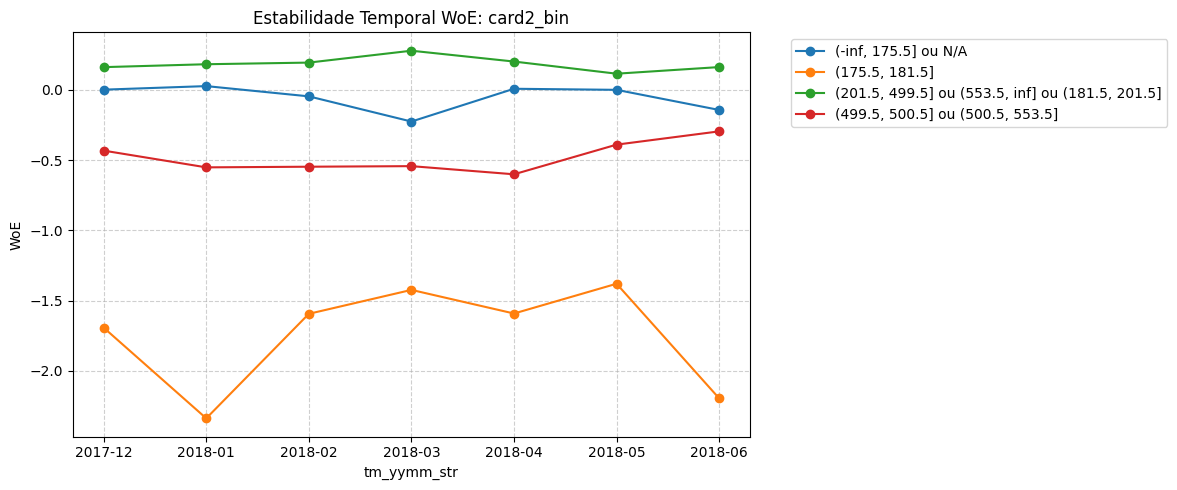

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
card3_bin,,,,,,,,
"(149.5, 174.5] ou (-inf, 118.5] ou (145.0, 149.5]","12,922","514,042",0.6254,0.9020,0.8923,0.3663,0.1013,0.4889
"(174.5, 185.5]","7,377","49,076",0.3570,0.0861,0.0956,-1.4221,0.3853,0.4889
"N/A ou (118.5, 145.0] ou (213.5, inf] ou (185.5, 213.5]",364,"6,759",0.0176,0.0119,0.0121,-0.3969,0.0023,0.4889
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4889,0.4889


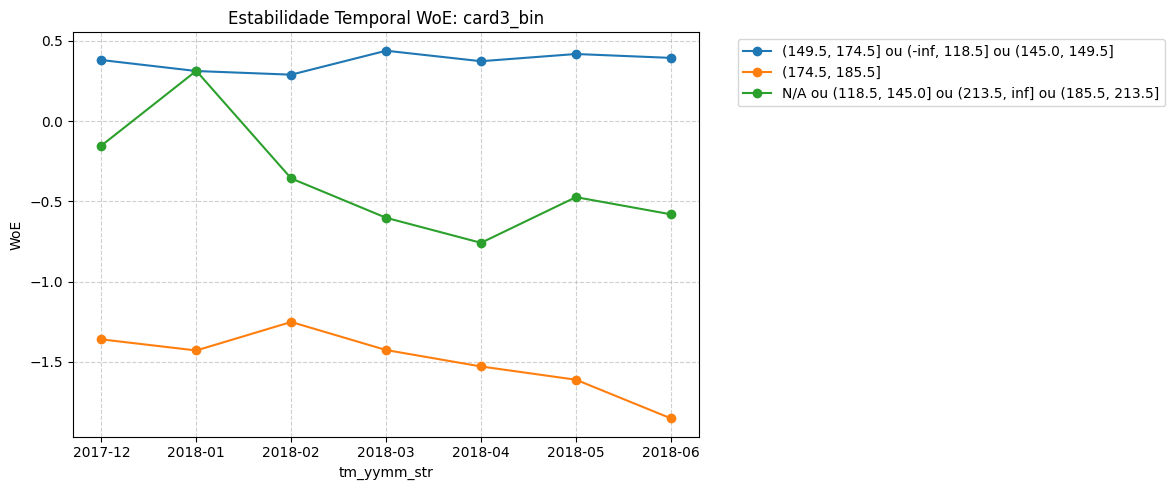

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
card5_bin,,,,,,,,
"(-inf, 108.0] ou (184.5, 224.5]","6,606","144,487",0.3197,0.2535,0.2559,-0.2319,0.0153,0.3040
"(136.5, 137.5]","1,725","9,995",0.0835,0.0175,0.0198,-1.5604,0.1029,0.3040
"(137.5, 162.5] ou N/A","2,360","29,627",0.1142,0.0520,0.0542,-0.7872,0.0490,0.3040
"(168.0, 184.5] ou (162.5, 168.0] ou (108.0, 136.5]","1,148","94,929",0.0556,0.1666,0.1627,1.0976,0.1218,0.3040
"(224.5, inf]","8,824","290,839",0.4270,0.5104,0.5074,0.1782,0.0148,0.3040
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.3040,0.3040


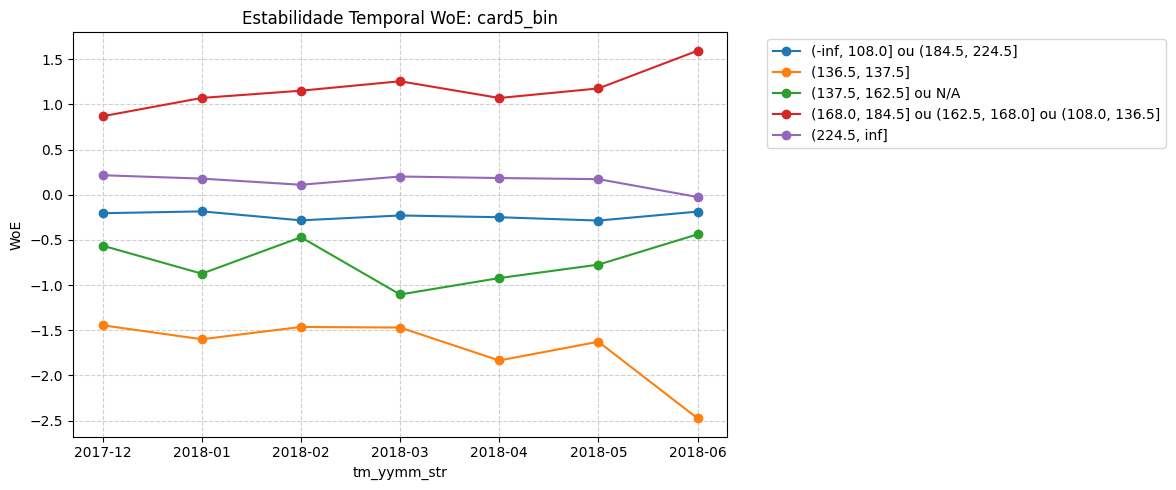

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
addr1_bin,,,,,,,,
"(122.5, 198.5] ou (-inf, 121.0]","2,112","97,370",0.1022,0.1709,0.1685,0.5136,0.0352,0.4584
"(535.5, inf] ou (121.0, 122.5] ou (198.5, 535.5]","10,810","414,542",0.5232,0.7274,0.7203,0.3296,0.0673,0.4584
N/A,"7,741","57,965",0.3746,0.1017,0.1113,-1.3038,0.3558,0.4584
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4584,0.4584


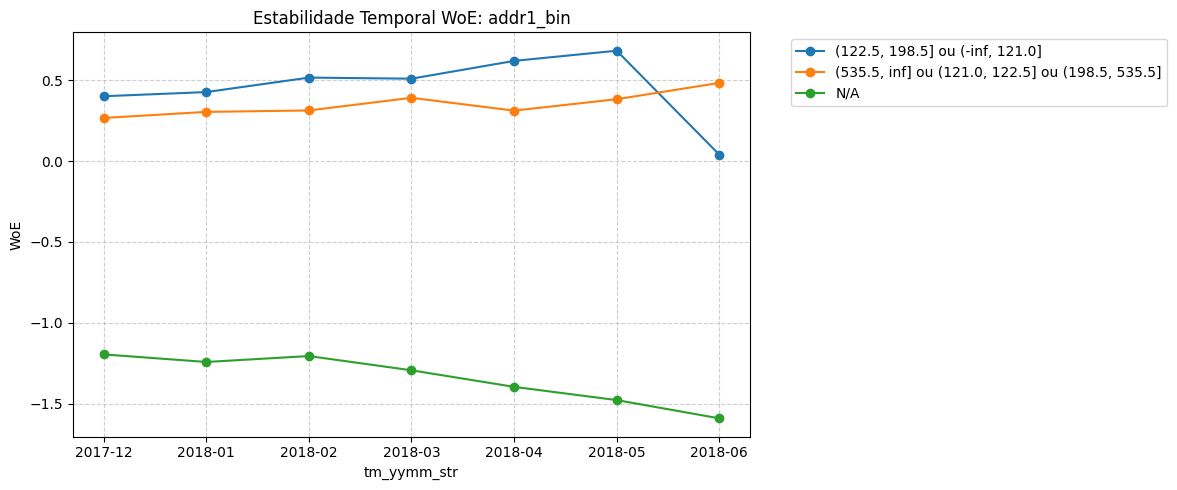

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
dist1_bin,,,,,,,,
"(1.5, 3.5]",350,"29,486",0.0169,0.0517,0.0505,1.1153,0.0388,0.1908
"(1802.5, inf] ou (0.5, 1.5]",623,"20,914",0.0302,0.0367,0.0365,0.1958,0.0013,0.1908
"(958.5, 976.5]",46,277,0.0022,0.0005,0.0005,-1.5307,0.0027,0.1908
"(976.5, 1802.5] ou (3.5, 78.5] ou (-inf, 0.5]","2,795","158,135",0.1353,0.2775,0.2725,0.7184,0.1022,0.1908
"N/A ou (78.5, 958.5]","16,849","361,065",0.8154,0.6336,0.6399,-0.2523,0.0459,0.1908
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1908,0.1908


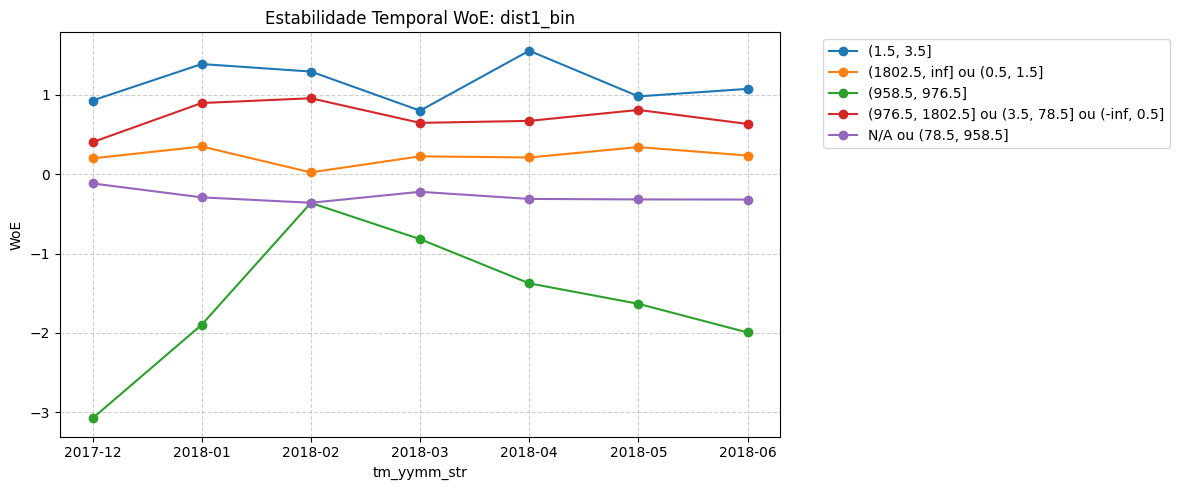

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
dist2_bin,,,,,,,,
"(-inf, 0.5]",540,"2,979",0.0261,0.0052,0.0060,-1.6100,0.0337,0.1563
"(1.5, 2.5] ou N/A","16,952","536,517",0.8204,0.9415,0.9372,0.1376,0.0167,0.1563
"(116.5, 1525.0] ou (0.5, 1.5] ou (2.5, 116.5] ou (1525.0, inf]","3,171","30,381",0.1535,0.0533,0.0568,-1.0574,0.1059,0.1563
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1563,0.1563


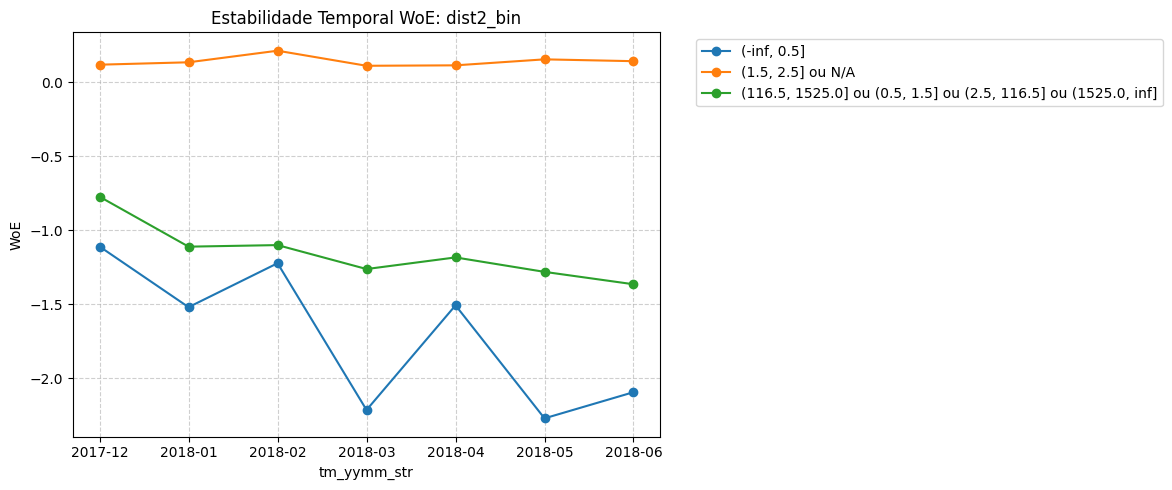

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C2_bin,,,,,,,,
"(187.5, 646.0]",619,"1,110",0.0300,0.0019,0.0029,-2.7334,0.0766,0.3358
"(2.5, 3.5] ou (1.5, 2.5]","5,196","150,522",0.2515,0.2641,0.2637,0.0491,0.0006,0.3358
"(3.5, 9.5]","3,740","68,401",0.1810,0.1200,0.1222,-0.4109,0.0251,0.3358
"(646.0, inf] ou (9.5, 76.5]","3,113","21,308",0.1507,0.0374,0.0414,-1.3937,0.1579,0.3358
"(76.5, 187.5] ou (-inf, 1.5]","7,995","328,536",0.3869,0.5765,0.5699,0.3987,0.0756,0.3358
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.3358,0.3358


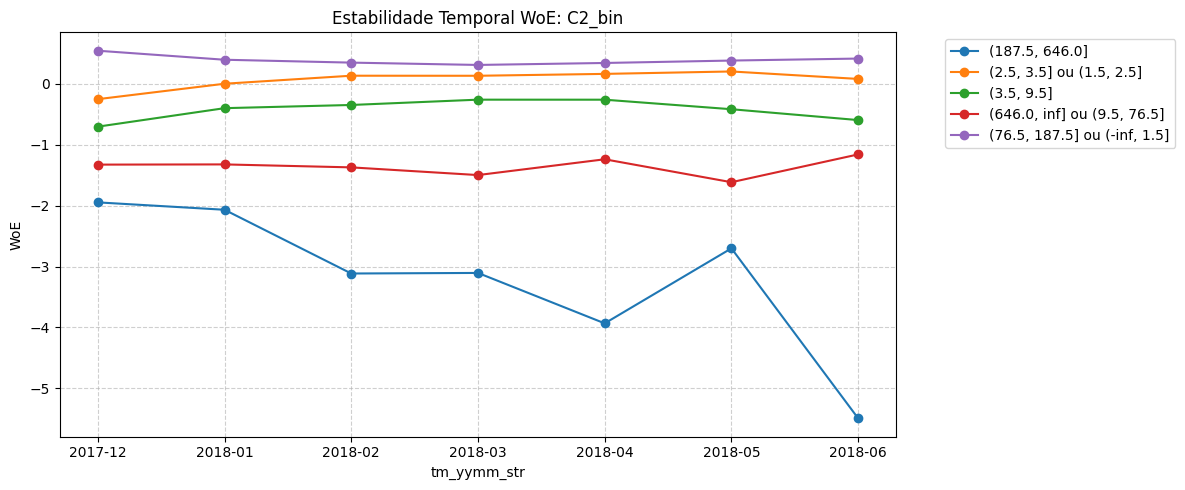

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C6_bin,,,,,,,,
"(-inf, 0.5] ou (0.5, 1.5] ou (58.5, 859.5]","11,503","400,922",0.5567,0.7035,0.6984,0.2341,0.0344,0.1235
"(1.5, 2.5]","3,259","82,844",0.1577,0.1454,0.1458,-0.0817,0.0010,0.1235
"(8.5, 58.5] ou (3.5, 8.5] ou (2.5, 3.5]","5,745","85,039",0.2780,0.1492,0.1537,-0.6224,0.0802,0.1235
"(859.5, inf]",156,"1,072",0.0075,0.0019,0.0021,-1.3924,0.0079,0.1235
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1235,0.1235


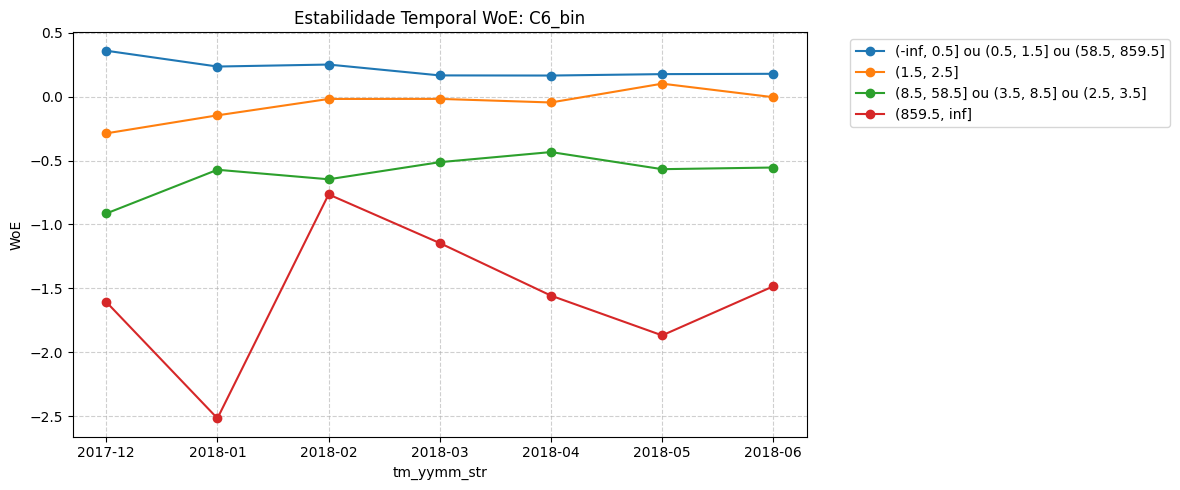

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C10_bin,,,,,,,,
"(-inf, 0.5]","9,646","443,796",0.4668,0.7788,0.7678,0.5117,0.1596,0.6727
"(118.5, inf] ou (0.5, 1.5]","4,865","97,684",0.2354,0.1714,0.1737,-0.3175,0.0203,0.6727
"(3.5, 6.5] ou (2.5, 3.5] ou (1.5, 2.5]","3,704","23,579",0.1793,0.0414,0.0462,-1.4662,0.2022,0.6727
"(6.5, 118.5]","2,448","4,818",0.1185,0.0085,0.0123,-2.6401,0.2905,0.6727
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.6727,0.6727


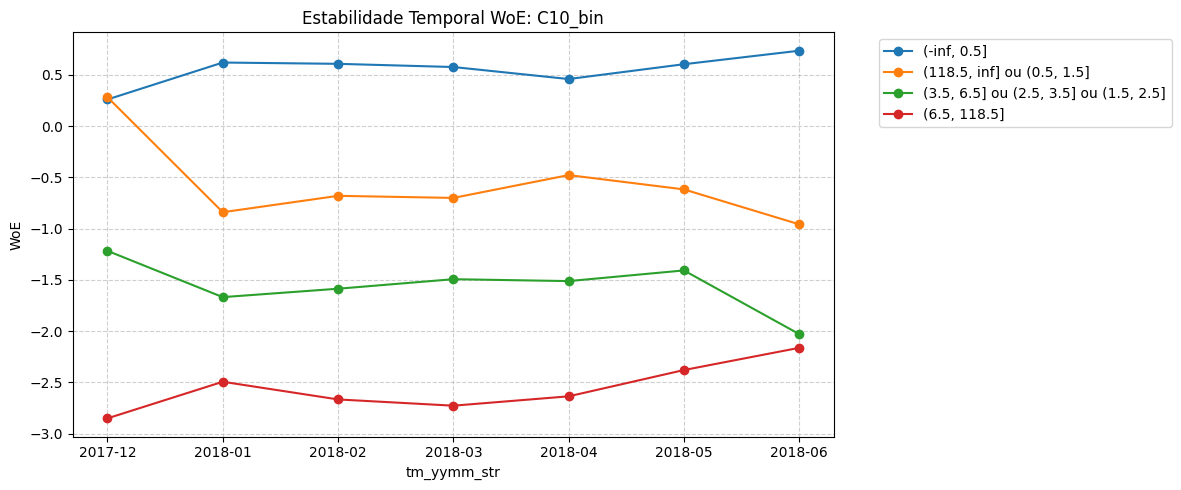

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C11_bin,,,,,,,,
"(0.5, 1.5] ou (52.5, 125.5]","10,355","397,906",0.5011,0.6982,0.6913,0.3316,0.0654,0.1827
"(125.5, inf]",706,"4,714",0.0342,0.0083,0.0092,-1.4190,0.0368,0.1827
"(13.5, 52.5] ou (3.5, 13.5] ou (-inf, 0.5] ou (1.5, 2.5]","7,976","134,420",0.3860,0.2359,0.2411,-0.4926,0.0740,0.1827
"(2.5, 3.5]","1,626","32,837",0.0787,0.0576,0.0584,-0.3119,0.0066,0.1827
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1827,0.1827


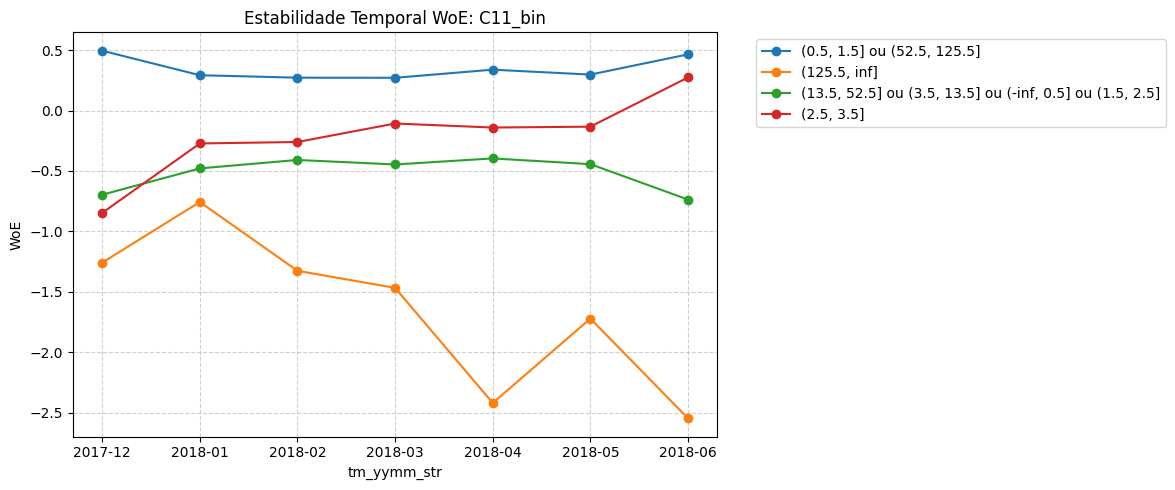

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
C12_bin,,,,,,,,
"(0.5, 1.5] ou (180.0, 644.5]","4,132","72,776",0.2000,0.1277,0.1302,-0.4485,0.0324,0.8080
"(1.5, 3.5]","1,987","14,440",0.0962,0.0253,0.0278,-1.3339,0.0945,0.8080
"(11.5, 180.0]","1,843",535,0.0892,0.0009,0.0040,-4.5533,0.4019,0.8080
"(3.5, 11.5]","1,384","3,136",0.0670,0.0055,0.0077,-2.4993,0.1537,0.8080
"(644.5, inf] ou (-inf, 0.5]","11,317","478,990",0.5477,0.8405,0.8303,0.4283,0.1254,0.8080
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.8080,0.8080


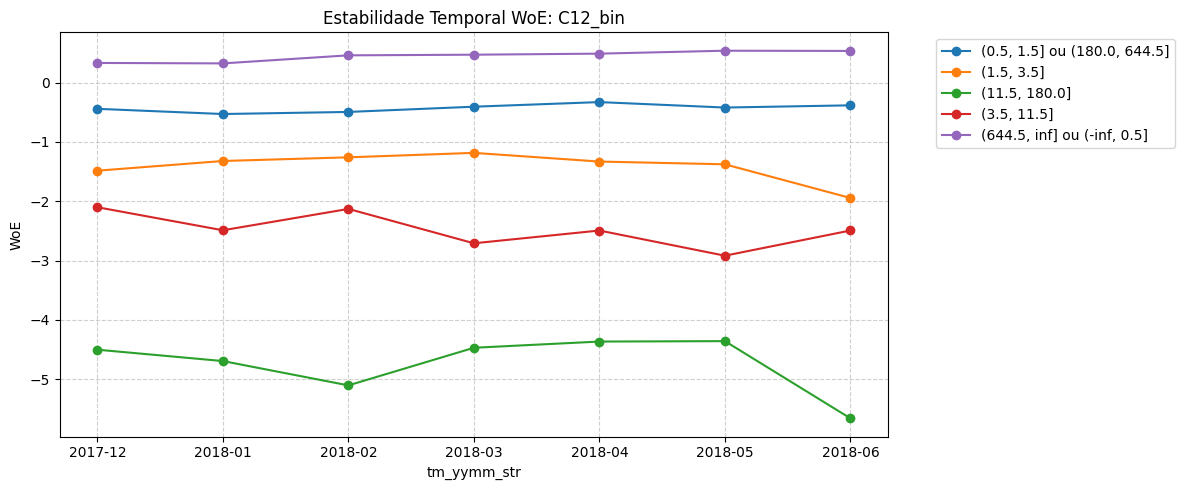

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D1_bin,,,,,,,,
"(0.5, 3.5]","1,997","15,560",0.0966,0.0273,0.0297,-1.2642,0.0877,0.2962
"(202.5, 555.5] ou (555.5, inf]","1,274","106,608",0.0617,0.1871,0.1827,1.1096,0.1391,0.2962
"(33.5, 202.5]","2,602","117,937",0.1259,0.2070,0.2041,0.4966,0.0402,0.2962
"N/A ou (3.5, 26.5] ou (-inf, 0.5] ou (26.5, 33.5]","14,790","329,772",0.7158,0.5787,0.5835,-0.2126,0.0292,0.2962
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2962,0.2962


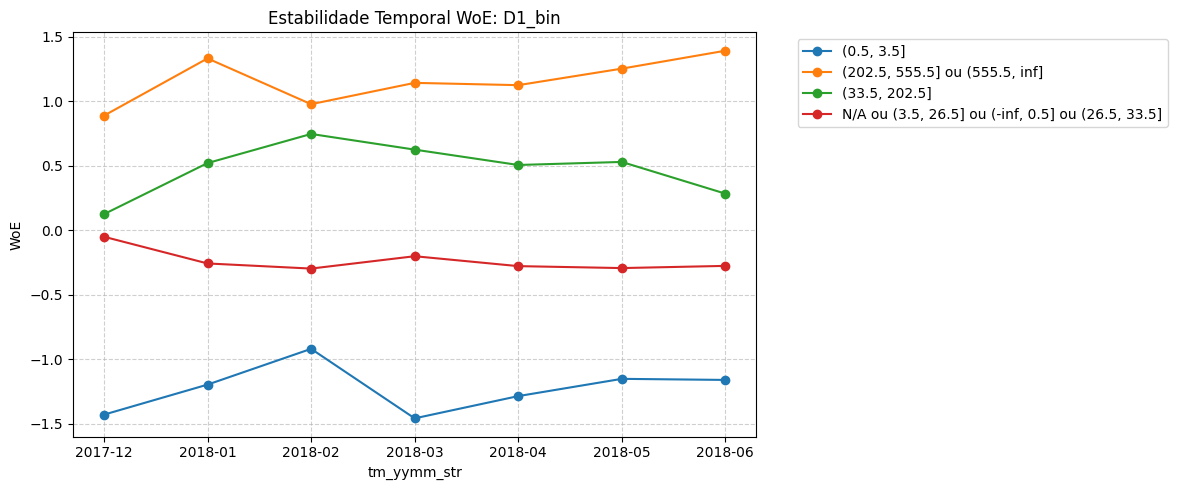

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D2_bin,,,,,,,,
"(-inf, 0.5] ou N/A ou (6.5, 11.5] ou (11.5, 33.5]","15,454","332,761",0.7479,0.5839,0.5897,-0.2475,0.0406,0.3508
"(0.5, 3.5]","1,534","13,251",0.0742,0.0233,0.0250,-1.1611,0.0592,0.3508
"(256.5, inf]",726,"82,347",0.0351,0.1445,0.1407,1.4134,0.1545,0.3508
"(3.5, 6.5]",616,"8,768",0.0298,0.0154,0.0159,-0.6622,0.0096,0.3508
"(33.5, 256.5]","2,333","132,750",0.1129,0.2329,0.2287,0.7240,0.0869,0.3508
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.3508,0.3508


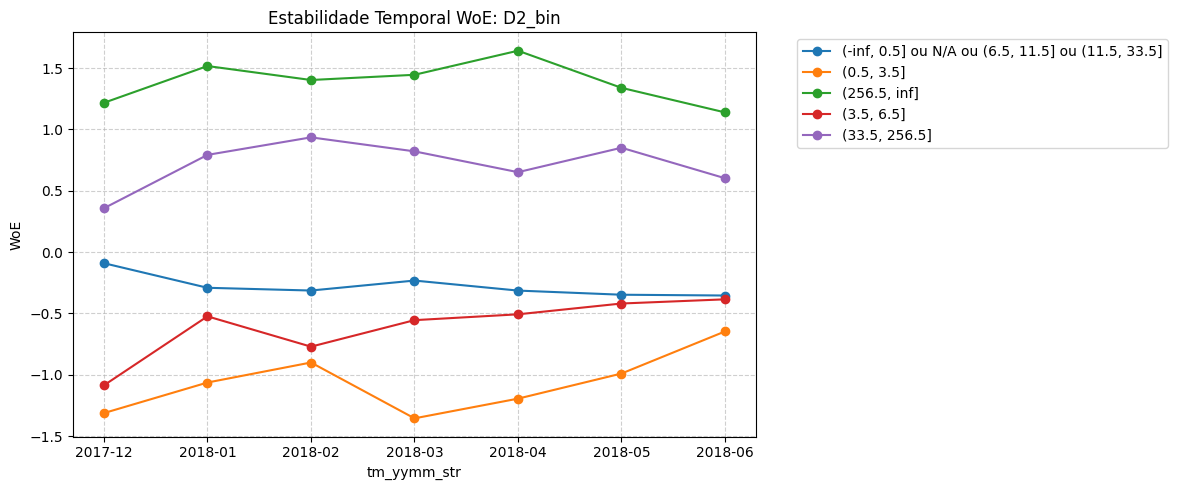

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D4_bin,,,,,,,,
"(0.5, 5.5]","1,895","13,903",0.0917,0.0244,0.0268,-1.3244,0.0892,0.1497
"(5.5, 27.5]","1,593","28,864",0.0771,0.0506,0.0516,-0.4204,0.0111,0.1497
"(559.5, inf]",100,"16,671",0.0048,0.0293,0.0284,1.7942,0.0438,0.1497
"N/A ou (-inf, 0.5] ou (282.5, 284.5] ou (27.5, 282.5] ou (284.5, 559.5]","17,075","510,439",0.8264,0.8957,0.8933,0.0806,0.0056,0.1497
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.1497,0.1497


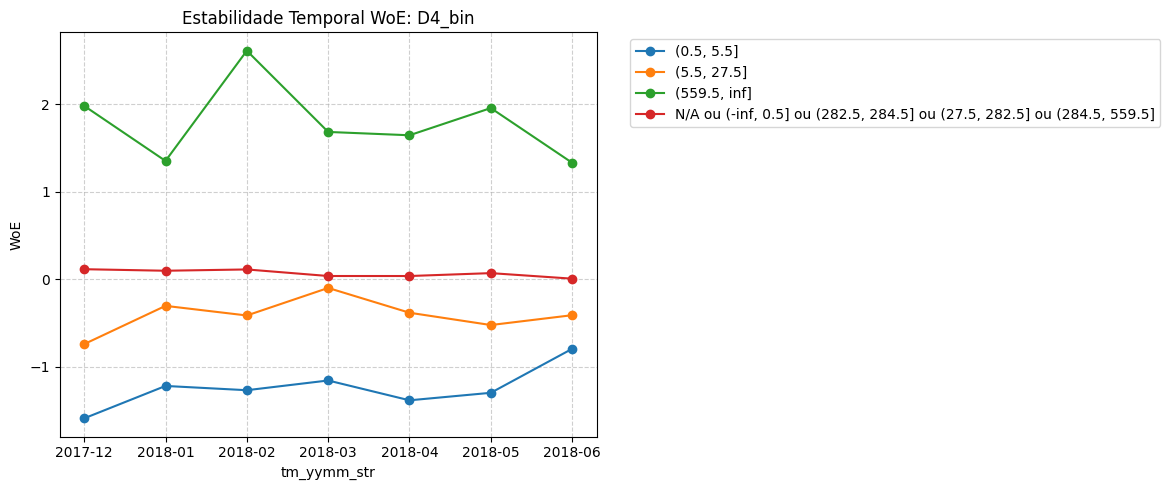

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D8_bin,,,,,,,,
"(-inf, 0.979]","3,288","15,555",0.1591,0.0273,0.0319,-1.7631,0.2325,0.5177
"(0.979, 5.354]","1,211","4,147",0.0586,0.0073,0.0091,-2.0864,0.1071,0.5177
"(129.271, 1155.896] ou N/A","13,586","525,869",0.6575,0.9228,0.9135,0.3389,0.0899,0.5177
"(30.521, 42.812] ou (5.354, 29.937] ou (1155.896, inf] ou (29.937, 30.521] ou (42.812, 129.271]","2,578","24,306",0.1248,0.0427,0.0455,-1.0735,0.0882,0.5177
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.5177,0.5177


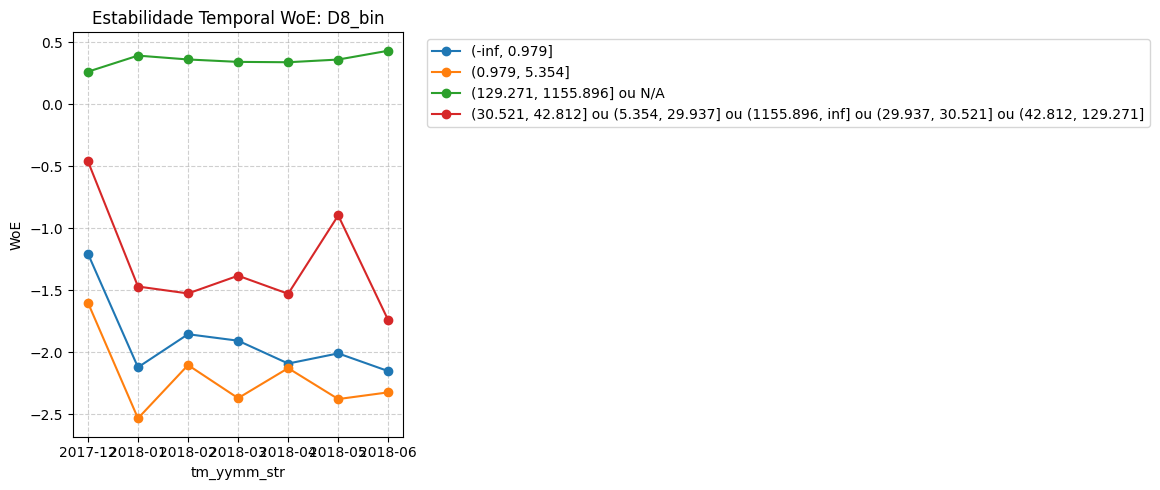

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D9_bin,,,,,,,,
"(0.229, 0.437] ou (0.146, 0.229]","1,482","6,061",0.0717,0.0106,0.0128,-1.9088,0.1166,0.4294
"(0.437, 0.479] ou (-inf, 0.146]","1,816","13,967",0.0879,0.0245,0.0267,-1.2772,0.0810,0.4294
"(0.521, 0.687]",965,"14,455",0.0467,0.0254,0.0261,-0.6109,0.0130,0.4294
"(0.687, 0.937] ou (0.479, 0.521] ou (0.937, inf]","3,564","32,616",0.1725,0.0572,0.0613,-1.1033,0.1272,0.4294
N/A,"12,836","502,778",0.6212,0.8823,0.8731,0.3508,0.0916,0.4294
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.4294,0.4294


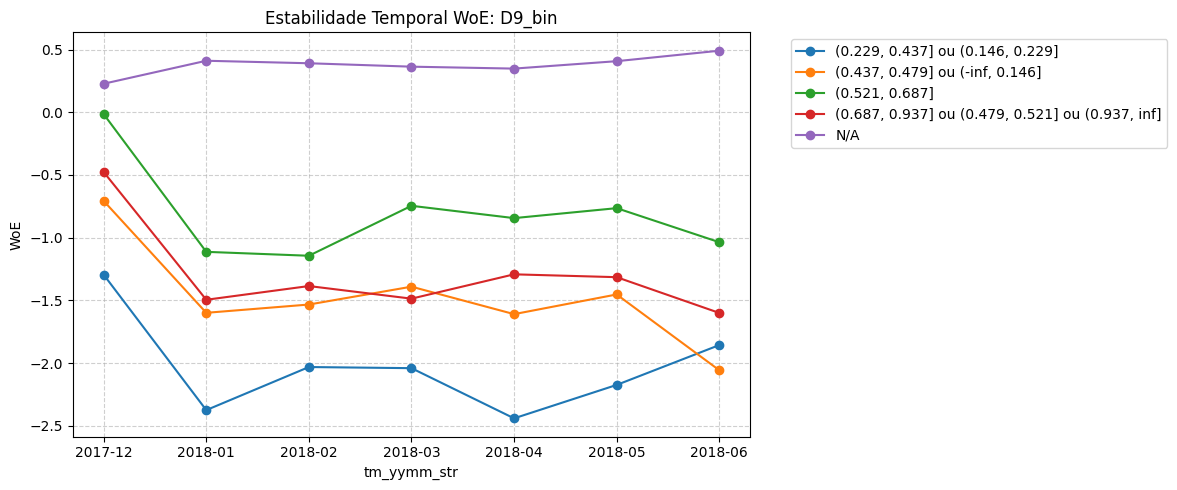

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D10_bin,,,,,,,,
"(-inf, 0.5] ou (13.5, 25.5]","11,059","229,234",0.5352,0.4023,0.4069,-0.2856,0.0380,0.2967
"(0.5, 2.5] ou N/A","4,767","79,923",0.2307,0.1402,0.1434,-0.4978,0.0450,0.2967
"(2.5, 13.5]","1,117","22,202",0.0541,0.0390,0.0395,-0.3279,0.0050,0.2967
"(25.5, 50.5] ou (50.5, 464.5]","3,167","188,645",0.1533,0.3310,0.3248,0.7699,0.1368,0.2967
"(464.5, inf]",553,"49,873",0.0268,0.0875,0.0854,1.1839,0.0719,0.2967
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2967,0.2967


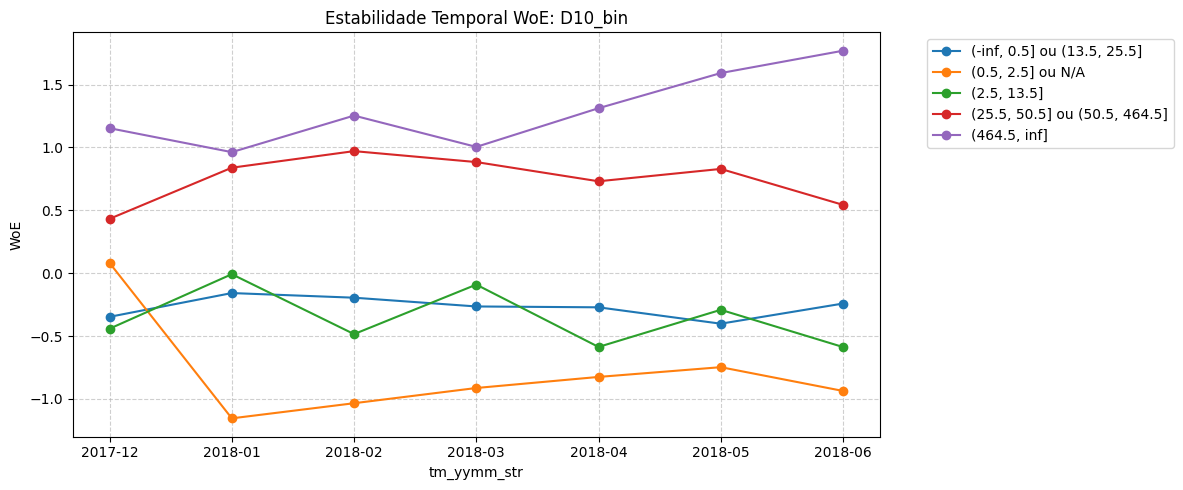

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D11_bin,,,,,,,,
"(0.5, 6.5]",851,"10,289",0.0412,0.0181,0.0189,-0.8252,0.0191,0.2018
"(104.5, 127.5] ou (397.5, inf]",480,"54,534",0.0232,0.0957,0.0932,1.4147,0.1025,0.2018
"(127.5, 367.5] ou (367.5, 397.5]","1,056","69,862",0.0511,0.1226,0.1201,0.8745,0.0625,0.2018
"N/A ou (6.5, 104.5] ou (-inf, 0.5]","18,276","435,192",0.8845,0.7637,0.7679,-0.1469,0.0177,0.2018
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2018,0.2018


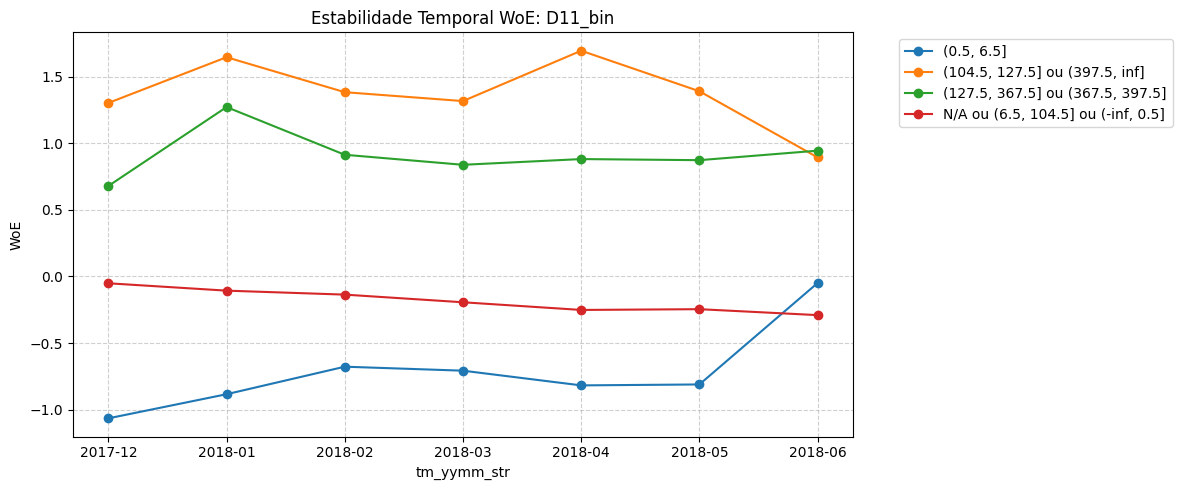

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
D15_bin,,,,,,,,
"(-inf, 0.5] ou (27.5, 71.5]","9,031","206,447",0.4371,0.3623,0.3649,-0.1877,0.0140,0.2587
"(0.5, 3.5] ou N/A","5,697","95,921",0.2757,0.1683,0.1721,-0.4935,0.0530,0.2587
"(3.5, 27.5]","2,008","36,945",0.0972,0.0648,0.0660,-0.4050,0.0131,0.2587
"(548.5, inf]",261,"31,136",0.0126,0.0546,0.0532,1.4626,0.0614,0.2587
"(71.5, 198.5] ou (198.5, 548.5]","3,666","199,428",0.1774,0.3499,0.3439,0.6792,0.1172,0.2587
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2587,0.2587


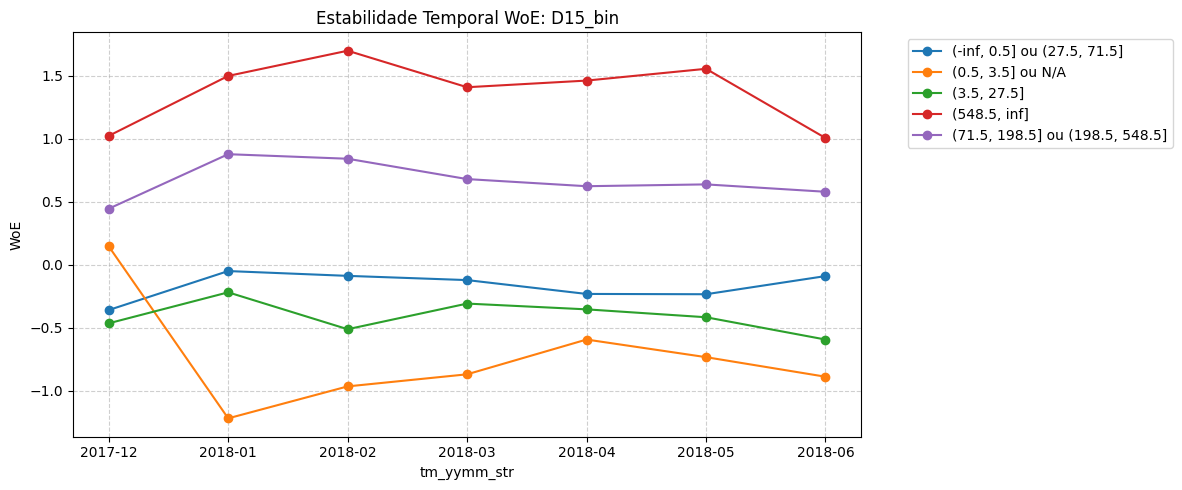

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V78_bin,,,,,,,,
"(0.5, 1.5] ou (-inf, 0.5]","11,983","446,503",0.5799,0.7835,0.7764,0.3009,0.0612,0.2966
"(11.5, inf] ou (5.5, 11.5]",661,"1,344",0.0320,0.0024,0.0034,-2.6078,0.0773,0.2966
"(3.5, 5.5] ou (2.5, 3.5]","1,604","7,917",0.0776,0.0139,0.0161,-1.7208,0.1097,0.2966
"N/A ou (1.5, 2.5]","6,415","114,113",0.3105,0.2002,0.2041,-0.4386,0.0483,0.2966
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2966,0.2966


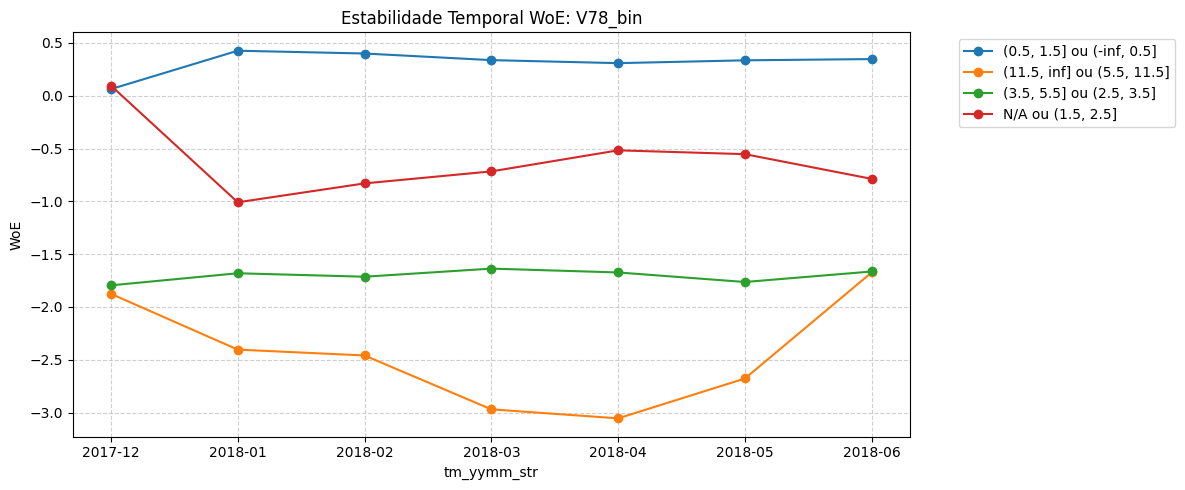

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V86_bin,,,,,,,,
"(0.5, 1.5]","12,288","464,623",0.5947,0.8153,0.8076,0.3155,0.0696,0.5175
"(1.5, 2.5] ou N/A ou (-inf, 0.5]","6,189","103,229",0.2995,0.1811,0.1853,-0.5030,0.0595,0.5175
"(2.5, 3.5]",870,"1,558",0.0421,0.0027,0.0041,-2.7346,0.1077,0.5175
"(3.5, 6.5]",909,406,0.0440,0.0007,0.0022,-4.1224,0.1785,0.5175
"(6.5, inf]",407,61,0.0197,0.0001,0.0008,-5.2081,0.1021,0.5175
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.5175,0.5175


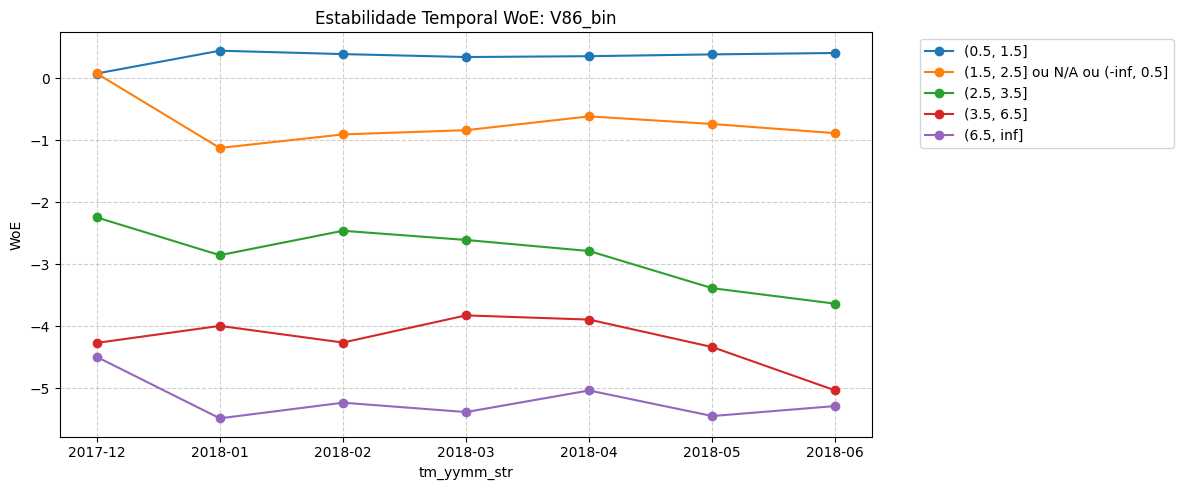

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V282_bin,,,,,,,,
"(-inf, 0.5]","3,557","209,255",0.1721,0.3672,0.3604,0.7574,0.1477,0.2868
"(0.5, 1.5]","12,020","304,435",0.5817,0.5342,0.5359,-0.0852,0.0040,0.2868
"(4.5, 8.5] ou (8.5, inf] ou (2.5, 4.5] ou (1.5, 2.5] ou N/A","5,086","56,187",0.2461,0.0986,0.1038,-0.9149,0.1350,0.2868
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2868,0.2868


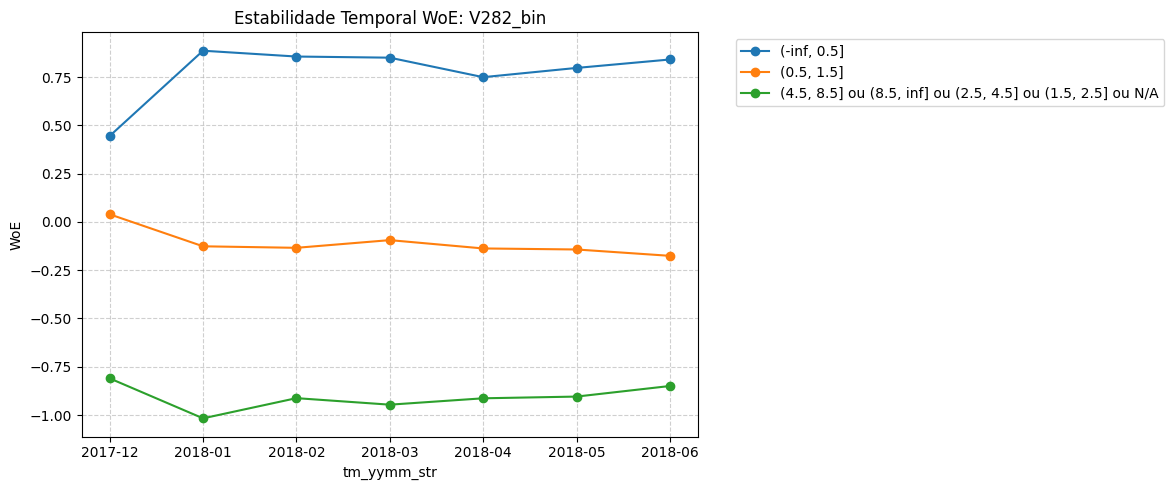

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V283_bin,,,,,,,,
"(-inf, 0.5]","3,521","207,978",0.1704,0.3650,0.3581,0.7615,0.1481,0.2958
"(0.5, 1.5]","10,132","274,467",0.4903,0.4816,0.4819,-0.0180,0.0002,0.2958
"(20.5, inf] ou (10.5, 20.5] ou (3.5, 10.5] ou (1.5, 3.5] ou N/A","7,010","87,432",0.3393,0.1534,0.1599,-0.7936,0.1475,0.2958
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.2958,0.2958


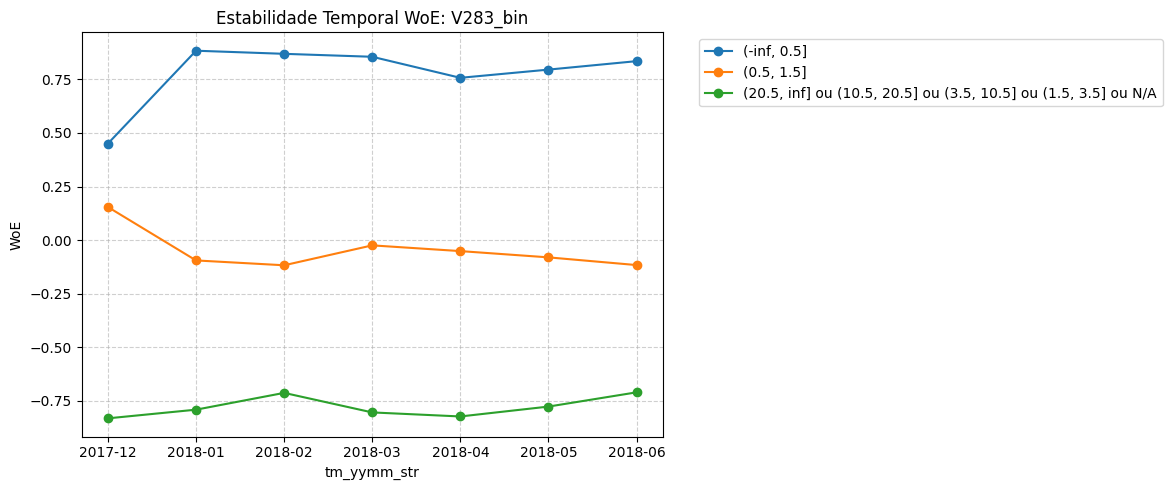

📊 Tabela de Information Value (Global):


,n_event,n_non_event,event_rate,non_event_rate,exposure,woe,iv,iv_total
V307_bin,,,,,,,,
"(4475.0, 57061.842] ou (1940.25, 4475.0]","1,165","11,018",0.0564,0.0193,0.0206,-1.0706,0.0397,0.0411
"(57061.842, inf] ou N/A ou (788.995, 1940.25] ou (444.985, 788.995] ou (342.817, 444.985] ou (-inf, 47.611] ou (47.611, 342.817]","19,498","558,859",0.9436,0.9807,0.9794,0.0385,0.0014,0.0411
__TOTAL__,"20,663","569,877",1.0000,1.0000,1.0000,nan,0.0411,0.0411


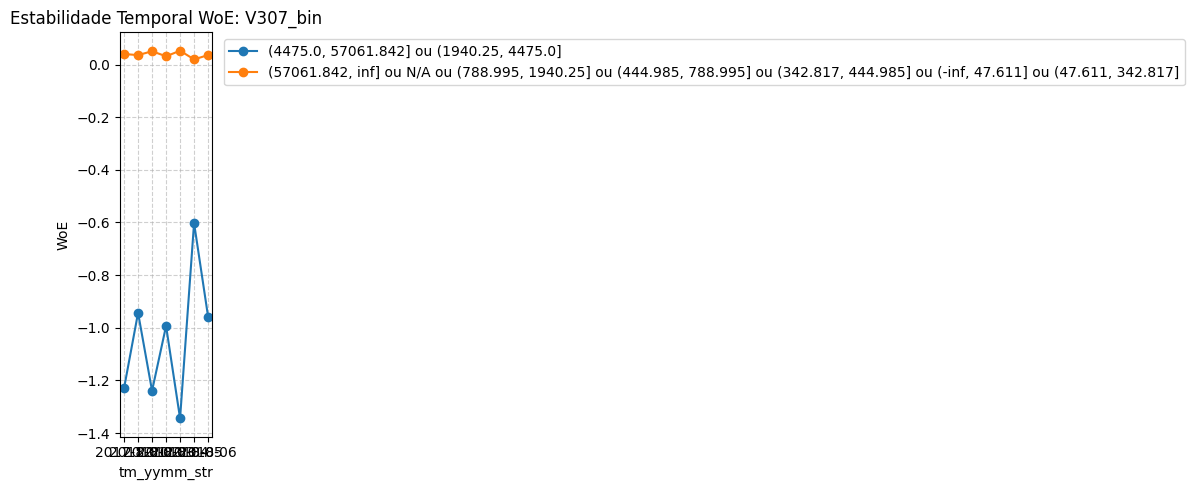

In [31]:
# %% [NB Step 10] Avaliação Completa: Tabela de WoE e Gráficos de Estabilidade
from IPython.display import HTML, display

from model_track.woe.stability import WoeStability


def gerar_tabela_woe_global(df, feature, target):
    """Gera a tabela analítica clássica de WoE/IV para uma variável."""

    # 1. Contagens Básicas
    stats = (
        df.groupby(feature, observed=True)[target]
        .agg(["count", "sum"])
        .rename(columns={"count": "exposure_count", "sum": "n_event"})
    )
    stats["n_non_event"] = stats["exposure_count"] - stats["n_event"]

    total_events = stats["n_event"].sum()
    total_non_events = stats["n_non_event"].sum()
    total_count = stats["exposure_count"].sum()

    # 2. Taxas Reais (Para exibição na tabela)
    stats["event_rate"] = stats["n_event"] / total_events
    stats["non_event_rate"] = stats["n_non_event"] / total_non_events
    stats["exposure"] = stats["exposure_count"] / total_count

    # 3. Taxas Suavizadas com Laplace (Para cálculo matemático sem erro de div/0)
    sm_event = (stats["n_event"] + 0.5) / (total_events + 0.5)
    sm_non_event = (stats["n_non_event"] + 0.5) / (total_non_events + 0.5)

    # Cálculo WoE e IV (Convenção: ln(Good/Bad))
    stats["woe"] = np.log(sm_non_event / sm_event)
    stats["iv"] = (sm_non_event - sm_event) * stats["woe"]
    stats["iv_total"] = stats["iv"].sum()

    # 4. Seleção e Ordenação
    cols = [
        "n_event",
        "n_non_event",
        "event_rate",
        "non_event_rate",
        "exposure",
        "woe",
        "iv",
        "iv_total",
    ]
    tabela = stats[cols].copy()

    # 5. Adiciona Linha de TOTAL
    tabela.loc["__TOTAL__"] = [
        total_events,
        total_non_events,
        tabela["event_rate"].sum(),
        tabela["non_event_rate"].sum(),
        tabela["exposure"].sum(),
        np.nan,  # WoE do total não faz sentido
        tabela["iv"].sum(),
        tabela["iv_total"].iloc[0],
    ]

    return tabela


# Inicializa a classe de estabilidade
ws = WoeStability(date_col="tm_yymm_str")

print(f"🔍 Iniciando auditoria para {len(dict_joined_categories)} variáveis...\n")

# Loop varrendo todas as features que foram agrupadas
for col_var in dict_joined_categories.keys():
    # Quebra visual no Jupyter para separar cada variável
    display(HTML(f"<hr><h3 style='color: #2c3e50;'>Variável: <b>{col_var}</b></h3>"))

    # --- 1. TABELA GLOBAL DE WOE ---
    tabela_analitica = gerar_tabela_woe_global(df_train, col_var, "isFraud")

    # Formatando para ficar bonito (com 4 casas decimais onde faz sentido)
    tabela_formatada = tabela_analitica.style.format(
        {
            "n_event": "{:,.0f}",
            "n_non_event": "{:,.0f}",
            "event_rate": "{:.4f}",
            "non_event_rate": "{:.4f}",
            "exposure": "{:.4f}",
            "woe": "{:.4f}",
            "iv": "{:.4f}",
            "iv_total": "{:.4f}",
        }
    ).background_gradient(subset=["woe"], cmap="coolwarm")

    print("📊 Tabela de Information Value (Global):")
    display(tabela_formatada)

    # --- 2. GRÁFICO DE ESTABILIDADE ---
    matriz_estabilidade = ws.calculate_stability_matrix(
        df_train, feature_col=col_var, target_col="isFraud"
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ws.generate_view(
        matrix=matriz_estabilidade, title=f"Estabilidade Temporal WoE: {col_var}", ax=ax
    )
    plt.show()

In [ ]:
# col_date = "tm_yymm_str"
# col_vr = "isFraud"
# col_var = top_numerical_features[16]


# ws = WoeStability(date_col=col_date)

# # tabela global
# global_woe = ws.global_table(
#     feature_col=col_var,
#     target_col=col_vr,
# )
# display(global_woe)
# # gráfico em subplot existente
# fig, ax = plt.subplots(1, 1, figsize=(8, 4))
# ws.generate_view(
#     feature_col=col_var,
#     target_col=col_vr,
#     ax=ax,
# )

In [33]:
import gc

import pandas as pd


class WoeCalculator:
    @staticmethod
    def preprocess_categories(df, columns):
        """Trata nulos e converte para string para consistência no mapeamento."""
        df_new = df.copy()
        for col in columns:
            df_new[col] = df_new[col].astype(str).replace(["nan", "None", "nan", "null", ""], "N/A")
        return df_new

    @staticmethod
    def compute_mapping(df, target_col, feature_col):
        """Gera o mapa WoE com ajuste de Laplace."""
        stats = df.groupby(feature_col, observed=True)[target_col].agg(["count", "sum"])
        stats.columns = ["Total", "Bad"]
        stats["Good"] = stats["Total"] - stats["Bad"]

        # Ajuste de Laplace para evitar log(0)
        perc_bad = (stats["Bad"] + 0.5) / (stats["Bad"].sum() + 0.5)
        perc_good = (stats["Good"] + 0.5) / (stats["Good"].sum() + 0.5)

        # ln(%Good / %Bad)
        return np.log(perc_good / perc_bad).to_dict()


# --- Execução do Pipeline de WoE ---

# 1. Tratamento Prévio de Nulos (Garante 'N/A')
df_train = WoeCalculator.preprocess_categories(df_train, top_features)
df_test = WoeCalculator.preprocess_categories(df_test, top_features)

all_woe_maps = {}
new_woe_cols_train = {}
new_woe_cols_test = {}

print(f"🧪 Fitando WoE em 'dev' para {len(top_features)} features...")

for col in top_features:
    # FIT: Apenas na amostra de desenvolvimento
    df_dev_temp = df_train.query("Amostra == 'dev'")
    mapping = WoeCalculator.compute_mapping(df_dev_temp, "isFraud", col)
    all_woe_maps[col] = mapping

    # TRANSFORM: Aplica no Train e Test
    # O .get(val, 0.0) garante que categorias novas (OOT/Test) recebam WoE 0
    new_col_name = f"{col}_woe"
    new_woe_cols_train[new_col_name] = df_train[col].map(mapping).fillna(0.0)
    new_woe_cols_test[new_col_name] = df_test[col].map(mapping).fillna(0.0)

# 2. Concatenação Final (Anti-Fragmentação)
df_train = pd.concat([df_train, pd.DataFrame(new_woe_cols_train, index=df_train.index)], axis=1)
df_test = pd.concat([df_test, pd.DataFrame(new_woe_cols_test, index=df_test.index)], axis=1)

# Limpeza
del new_woe_cols_train, new_woe_cols_test
gc.collect()

print("✅ WoE aplicado com sucesso. Categorias não vistas em 'dev' mapeadas para 0.0.")

🧪 Fitando WoE em 'dev' para 30 features...
✅ WoE aplicado com sucesso. Categorias não vistas em 'dev' mapeadas para 0.0.


In [34]:
from scipy.stats import ks_2samp
from sklearn.linear_model import LogisticRegression

# Features finais (apenas os campos WoE)
final_features = [f"{c}_woe" for c in top_features]

# Filtro de Amostras
X_dev = df_train.query("Amostra == 'dev'")[final_features]
y_dev = df_train.query("Amostra == 'dev'")["isFraud"]

X_oot = df_train.query("Amostra == 'oot'")[final_features]
y_oot = df_train.query("Amostra == 'oot'")["isFraud"]

# 1. Ajuste do Modelo
lr_model = LogisticRegression(class_weight="balanced", solver="lbfgs", max_iter=1000)
lr_model.fit(X_dev, y_dev)

# 2. Predição Probabilística
df_train["proba"] = lr_model.predict_proba(df_train[final_features])[:, 1]


# 3. Cálculo de KS por período
def calculate_metrics(data):
    # AUC
    auc = roc_auc_score(data["isFraud"], data["proba"])
    # KS (Distância máxima entre acumulado de bons e maus)
    bads = data.loc[data["isFraud"] == 1, "proba"]
    goods = data.loc[data["isFraud"] == 0, "proba"]
    ks = ks_2samp(bads, goods).statistic
    return pd.Series({"AUC": auc, "KS": ks})


performance_summary = df_train.groupby("tm_yymm_str").apply(calculate_metrics).reset_index()

print("\n🏆 PERFORMANCE POR MÊS (MODELO FINAL):")
display(performance_summary)


🏆 PERFORMANCE POR MÊS (MODELO FINAL):


/var/folders/0m/mtf6psc91_l02bjt_n2nd7bh0000gn/T/ipykernel_11837/2510102015.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  performance_summary = df_train.groupby('tm_yymm_str').apply(calculate_metrics).reset_index()


,tm_yymm_str,AUC,KS
0,2017-12,0.781471,0.431942
1,2018-01,0.832576,0.519451
2,2018-02,0.840703,0.525081
3,2018-03,0.818699,0.488222
4,2018-04,0.820227,0.492385
5,2018-05,0.813107,0.474204
6,2018-06,0.826782,0.573760


### 📘 Como ler essa tabela para concluir seu raciocínio:

1.  **Foco na Captura:** Se o seu chefe perguntar: "Cristiano, como pegamos **50% das fraudes** do mês que vem?", você olha a linha de 50%.
2.  **Custo de Reprovação:** Na segunda coluna, você verá o impacto. Exemplo: Se estiver 3%, você diz: "Precisamos negar **3% do volume total de pedidos** para dar o tombo em metade das fraudes".
3.  **Hit Rate (Precisão):** Essa coluna é vital. Se ela estiver em 40%, significa que em cada 10 pedidos que você barrou para atingir essa meta, 4 eram fraudes reais e 6 eram clientes bons que foram impactados (Falso Positivo).
4.  **Ponto de Corte:** É o valor de 0 a 1 que você vai configurar no sistema de aprovação.


In [43]:
import pandas as pd


def gerar_tabela_captura_fraude(df, target_col, proba_col):
    """
    Gera a tabela focada em: Para pegar X% da fraude, quanto do total eu reprovo?
    """
    # 1. Ordenar por score decrescente
    df_sorted = (
        df[[target_col, proba_col]]
        .sort_values(by=proba_col, ascending=False)
        .reset_index(drop=True)
    )

    total_fraudes = df_sorted[target_col].sum()
    total_pedidos = len(df_sorted)

    # 2. Cálculos acumulados
    df_sorted["fraudes_capturadas_acum"] = df_sorted[target_col].cumsum()
    df_sorted["tpr_acum"] = df_sorted["fraudes_capturadas_acum"] / total_fraudes

    # 3. Níveis de captura desejados (o quanto da fraude queremos pegar)
    captura_alvo = [
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
        0.50,
        0.60,
        0.70,
        0.80,
        0.90,
    ]

    linhas = []
    for alvo in captura_alvo:
        # Encontrar o primeiro registro onde a captura acumulada atinge o alvo
        idx = (df_sorted["tpr_acum"] >= alvo).idxmax()
        registro = df_sorted.iloc[idx]

        # Quantos pedidos acumulados até aqui?
        qtd_pedidos_reprovados = idx + 1
        pct_total_pedidos = (qtd_pedidos_reprovados / total_pedidos) * 100

        # Métricas acessórias
        tpr_real = registro["tpr_acum"] * 100
        fnr = 100 - tpr_real  # O que escapou da fraude total
        cutoff = registro[proba_col]

        # Precisão (Hit Rate): De tudo que eu reprovei nesse nível, quanto era fraude?
        hit_rate = (registro["fraudes_capturadas_acum"] / qtd_pedidos_reprovados) * 100

        linhas.append(
            {
                "Captura Alvo (Fraude Total %)": int(alvo * 100),
                "Total de Ordens Reprovadas (%)": round(pct_total_pedidos, 2),
                "True Positive Rate Real (%)": round(tpr_real, 2),
                "False Negative Rate (%)": round(fnr, 2),
                "Hit Rate (Precisão %)": round(hit_rate, 2),
                "Ponto de Corte (Score)": round(cutoff, 4),
            }
        )

    return pd.DataFrame(linhas)


# Gerando a tabela para a amostra OOT (Validação Temporal)
df_oot = df_train.query("Amostra == 'oot'").copy()
tabela_decisao = gerar_tabela_captura_fraude(df_oot, "isFraud", "proba")

print("🛡️ ESTRATÉGIA DE CAPTURA DE FRAUDE (OOT):")
display(tabela_decisao)

🛡️ ESTRATÉGIA DE CAPTURA DE FRAUDE (OOT):


,Captura Alvo (Fraude Total %),Total de Ordens Reprovadas (%),True Positive Rate Real (%),False Negative Rate (%),Hit Rate (Precisão %),Ponto de Corte (Score)
0,5,0.19,5.01,94.99,89.94,0.9913
1,10,0.40,10.02,89.98,86.56,0.9822
2,15,0.69,15.00,85.00,75.08,0.9645
3,20,1.17,20.01,79.99,59.59,0.9339
4,25,1.84,25.02,74.98,47.16,0.8975
5,30,3.26,30.00,70.00,31.95,0.8496
6,35,4.45,35.01,64.99,27.37,0.8013
7,40,5.81,40.02,59.98,23.95,0.7582
8,45,7.36,45.00,55.00,21.25,0.7157
9,50,9.38,50.02,49.98,18.54,0.6674


In [44]:
# Se eu quiser capturar exatamente 50% da fraude, qual o score de corte?
score_corte = np.interp(
    50, tabela_decisao["True Positive Rate Real (%)"], tabela_decisao["Ponto de Corte (Score)"]
)
reprovacao_total = np.interp(
    50,
    tabela_decisao["True Positive Rate Real (%)"],
    tabela_decisao["Total de Ordens Reprovadas (%)"],
)
taxa_evento = df_train["isFraud"].mean() * 100
print("🎯 Para capturar 50% da fraude:")
print(f"   -> Corte o score em: {score_corte:.4f}")
print(f"   -> Isso vai reprovar {reprovacao_total:.2f}% de todas as suas ordens.")
print(f"   -> Sua taxa de evento é de {taxa_evento:.2f}%.")

🎯 Para capturar 50% da fraude:
   -> Corte o score em: 0.6676
   -> Isso vai reprovar 9.37% de todas as suas ordens.
   -> Sua taxa de evento é de 3.50%.
